september 30th current data analysis
october 21th still useful


In [110]:
#this method is updated since Oct 21. A better implementation would be to skip the header, then use vectorized operation in numpy.
#binparserGraph
#binparserTemp
#temporary binary parser before we can get xml analysis working

import os
import struct
import pandas as pd
import numpy as np

def parse_payload(payload: bytes):
    # payload = 4B header + 8B timestamp + 70B data (14×5B entries)
    timestamp = struct.unpack('<Q', payload[4:12])[0]
    entries = payload[12:]
    data_dict = {}
    for i in range(0, len(entries), 5):
        char_id = chr(entries[i])
        value = struct.unpack('<f', entries[i+1:i+5])[0]
        data_dict[char_id] = value
    return timestamp, data_dict

def parse_binary_folder(folder_path: str):
    # 4-byte discard field, then 8-byte timestamp, then 16 × (1-byte id + 4-byte float)
    record_dtype = np.dtype([
        ('_discard', '4u1'),                 # 4 bytes
        ('timestamp', '<u8'),                # 8 bytes (uint64)
        ('pairs', [('id', 'u1'), ('data', '<f4')], (16,))  # 16 × (1+4)
    ])
    record_size = record_dtype.itemsize  # should be 92 bytes

    files = sorted(
        [f for f in os.listdir(folder_path) if f.startswith('data') and f.endswith('.bin')],
        key=lambda x: int(x[4:-4])
    )

    timestamps_all = []
    id_arrays = {i: [] for i in range(16)}  # accumulate data columns by slot
    id_chars = None                         # to hold column names (char IDs)

    for filename in files:
        path = os.path.join(folder_path, filename)

        with open(path, 'rb') as f:
            data_bytes = f.read()  # read entire file (no header)
            n_records = len(data_bytes) // record_size
            if n_records == 0:
                continue

            # vectorized read
            arr = np.frombuffer(data_bytes, dtype=record_dtype, count=n_records)

            timestamps = arr['timestamp']
            ids = arr['pairs']['id']       # shape (n_records, 16)
            vals = arr['pairs']['data']    # shape (n_records, 16)

            timestamps_all.append(timestamps)

            # verify consistent IDs per column
            first_ids = ids[0, :]
            if not np.all(ids == first_ids):
                mismatched = np.nonzero(~np.all(ids == first_ids, axis=1))[0][:5]
                print(f"\n[DEBUG] ID mismatch in file {filename}: showing first {len(mismatched)} bad rows")
                print("Expected IDs (bytes):", " ".join(f"{b:02X}" for b in first_ids))
                for idx in mismatched:
                    raw_hex = " ".join(f"{b:02X}" for b in ids[idx])
                    print(f"  Row {idx:>6}: {raw_hex}")
                raise ValueError(f"File {filename} has mixed IDs per column!")

            # store char representations once (from first file)
            if id_chars is None:
                id_chars = [chr(x) for x in first_ids]

            # accumulate per-ID arrays
            for i, id_val in enumerate(first_ids):
                id_arrays[i].append(vals[:, i])

    if not timestamps_all:
        raise ValueError("No valid records found in folder!")

    # concatenate across files
    timestamps_all = np.concatenate(timestamps_all)
    data_cols = {}
    for i, chunks in id_arrays.items():
        if len(chunks) == 0:
            continue
        colname = id_chars[i] if id_chars is not None else f"id_{i}"
        data_cols[colname] = np.concatenate(chunks)

    # Build DataFrame
    df = pd.DataFrame(data_cols)
    df.insert(0, "timestamp", timestamps_all.astype(np.uint64))

    return df

def find_rollovers(df):
    if df['timestamp'].dtype != 'uint64':
        df['timestamp'] = df['timestamp'].astype('uint64')

    # Diff using int64 to preserve exact rollover detection
    diffs = df['timestamp'].astype('int64').diff()

    rollover_points = df.index[diffs < 0].tolist()

    for idx in rollover_points:
        t_before = df.loc[idx - 1, 'timestamp']
        t_after = df.loc[idx, 'timestamp']
        print(f"Timestamp rollover at index {idx}: {t_before} → {t_after}")

    return rollover_points

# Example usage:
df = parse_binary_folder('C:/Users/andyh/Downloads/serialreceive/mssRising/teensy')
print(df.head(150))

print (df.iloc[12:75].head(10))

rollover = find_rollovers(df)
print(rollover)

print(df.shape)

          timestamp         A         B         C         D         H  \
0    13030525993683  1.212511  0.068633  0.983735  0.228776  0.011439   
1    13030526512183  1.212511  0.068633  0.983735  0.228776  0.011439   
2    13030527030808  1.212511  0.068633  0.983735  0.228776  0.011439   
3    13030527549475  1.212511  0.068633  0.983735  0.228776  0.011439   
4    13030528068100  1.212511  0.068633  0.983735  0.228776  0.011439   
..              ...       ...       ...       ...       ...       ...   
145  13030601293100  1.212511  0.068633  0.983735  0.228776  0.011439   
146  13030601811767  1.212511  0.068633  0.983735  0.228776  0.011439   
147  13030602330433  1.212511  0.068633  0.983735  0.228776  0.011439   
148  13030602849017  1.212511  0.068633  0.983735  0.228776  0.011439   
149  13030603367517  1.212511  0.068633  0.983735  0.228776  0.011439   

            I         J         K         Y         Z         O         P  \
0    2.608043  0.011439  0.125827  4.332778  4

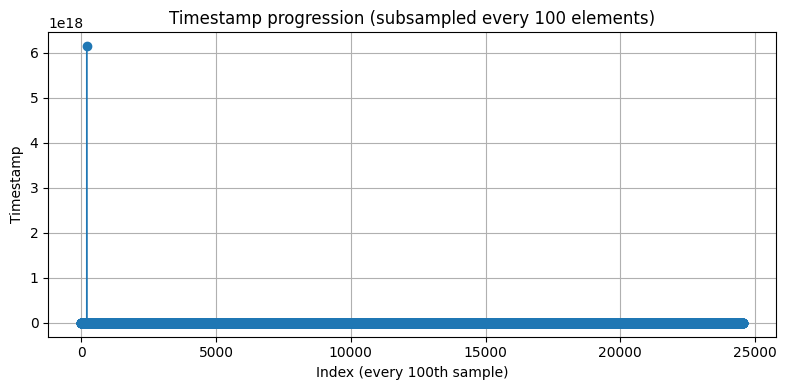

In [2]:
import matplotlib.pyplot as plt
point = 2747287
ts_sub_1 = df["timestamp"].iloc[::100].reset_index(drop=True)
# Plot timestamp vs index
plt.figure(figsize=(8, 4))
plt.plot(ts_sub_1.index, ts_sub_1, marker='o', linestyle='-', linewidth=1)

plt.xlabel("Index (every 100th sample)")
plt.ylabel("Timestamp")
plt.title("Timestamp progression (subsampled every 100 elements)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# USE ONLY FOR ONLY TEENSY
import pandas as pd

def correct_timestamp_overflow(df: pd.DataFrame, time_col: str = "timestamp",
                               overflow_points=None, overflow_constant=None) -> pd.DataFrame:
    """
    Correct timestamp overflows by adding multiples of overflow_constant
    after each detected overflow point.

    Parameters:
        df (pd.DataFrame): Input DataFrame with timestamp column.
        time_col (str): Name of the timestamp column.
        overflow_points (list[int]): List of row indices where overflow occurs.
        overflow_constant (int): The value to add after each overflow (e.g. 2**32).
    
    Returns:
        pd.DataFrame: Copy of df with corrected timestamp column.
    """
    if overflow_points is None or overflow_constant is None:
        raise ValueError("Must provide overflow_points and overflow_constant")

    result_df = df.copy()
    corrected = result_df[time_col].astype("int64").copy()

    offset = 0
    current_overflow_idx = 0

    # Iterate over rows, adding offsets after each overflow point
    for i in range(len(corrected)):
        if (current_overflow_idx < len(overflow_points)
                and i >= overflow_points[current_overflow_idx]):
            # Passed an overflow point -> increase offset
            current_overflow_idx += 1
            offset += overflow_constant
        corrected.iloc[i] += offset

    result_df[time_col] = corrected
    return result_df

# Overflow constant for 32-bit counter converted to nanosecond
OVERFLOW_CONST = 2**32 * 125 / 3

corrected_df = correct_timestamp_overflow(df, overflow_points=rollover, overflow_constant=OVERFLOW_CONST)

#print(corrected_df.head(10))
testrollover= find_rollovers(corrected_df)
print(testrollover)
#print(corrected_df.iloc[120:135].head(10))
#print(df.iloc[120:135].head(10))
import matplotlib.pyplot as plt

ts_sub = corrected_df["timestamp"].iloc[::100].reset_index(drop=True)

# Plot timestamp vs index
plt.figure(figsize=(8, 4))
plt.plot(ts_sub.index, ts_sub, marker='o', linestyle='-', linewidth=1)

plt.xlabel("Index (every 100th sample)")
plt.ylabel("Timestamp")
plt.title("Timestamp progression (subsampled every 100 elements)")
plt.grid(True)
plt.tight_layout()
plt.show()

🗑️  Dropped 40 rows around 8 overflow point(s).
[]


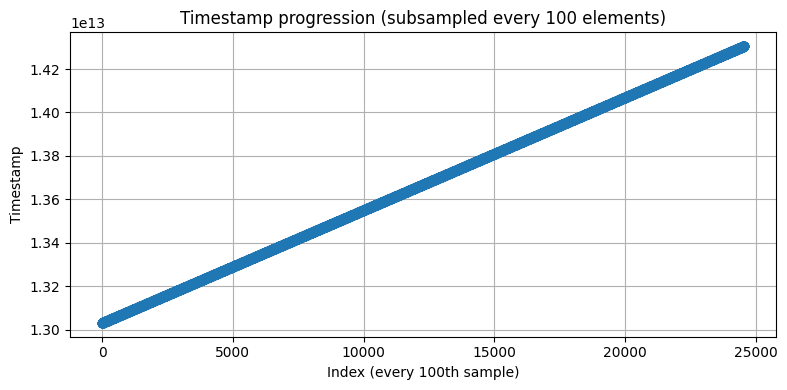

In [111]:
#drop rows time anomaly
#sometimes there WILL BE race conditions causing time anomalies, very few. 2 datapoints every 10,000 or so
#   this function is the alternative to fixing overflows. This one drops 2 before and after the anomaly singleton. 
import pandas as pd

def drop_around_overflows(df: pd.DataFrame,
                          overflow_points: list[int],
                          time_col: str = "timestamp",
                          window: int = 2) -> pd.DataFrame:
    """
    Drop rows around each overflow point, including the overflow itself.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        overflow_points (list[int]): List of row indices where overflow occurs.
        time_col (str): Timestamp column name (for reference/logging).
        window (int): Number of rows before and after to drop around each overflow point.

    Returns:
        pd.DataFrame: Copy of df with affected rows removed.
    """
    if overflow_points is None or len(overflow_points) == 0:
        print("⚠️ No overflow points provided — returning original DataFrame.")
        return df.copy()

    n_rows = len(df)
    to_drop = set()

    # For each overflow index, mark rows to drop: (i - window) ... (i + window)
    for idx in overflow_points:
        start = max(0, idx - window)
        end = min(n_rows - 1, idx + window)
        to_drop.update(range(start, end + 1))

    result_df = df.drop(index=sorted(to_drop))
    dropped_count = len(to_drop)

    print(f"🗑️  Dropped {dropped_count} rows around {len(overflow_points)} overflow point(s).")
    return result_df.reset_index(drop=True)

corrected_df = drop_around_overflows(df, overflow_points=rollover)
leftover = find_rollovers(corrected_df)
print(leftover)
import matplotlib.pyplot as plt
ts_sub_1 = corrected_df["timestamp"].iloc[::100].reset_index(drop=True)
# Plot timestamp vs index
plt.figure(figsize=(8, 4))
plt.plot(ts_sub_1.index, ts_sub_1, marker='o', linestyle='-', linewidth=1)

plt.xlabel("Index (every 100th sample)")
plt.ylabel("Timestamp")
plt.title("Timestamp progression (subsampled every 100 elements)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [112]:
#use this to read rapl if it's PKG, DRAM and PSYS
import os
import glob
import numpy as np
import pandas as pd
import struct

import os
import glob
import numpy as np
import pandas as pd

def read_rapl_binaries(SAMP_PATH):
    """
    Reads all binary files written by flush_to_file() in C:
        fwrite(ts_buf, sizeof(int64_t), BUF_SIZE, f);
        fwrite(e_buf, sizeof(float),   BUF_SIZE, f);

    Each file contains two contiguous arrays:
        - timestamps (int64 nanoseconds)
        - energy samples (float32 joules)
    Returns a pandas DataFrame with columns ['timestamp_ns', 'energy'].
    """

    # Match pattern like rapl_YYYYMMDD_HHMMSS_###.bin
    files = sorted(glob.glob(os.path.join(SAMP_PATH, "rapl_????????_??????_???.bin")))
    if not files:
        raise FileNotFoundError(f"No RAPL binary files found in {SAMP_PATH}")

    dfs = []
    for fname in files:
        with open(fname, "rb") as f:
            raw = f.read()

        # Each file contains BUF_SIZE timestamps (8 bytes each) + BUF_SIZE floats (4 bytes each) *3
        # So total length must be divisible by 20
        if len(raw) % 20 != 0:
            raise ValueError(f"File {fname} length {len(raw)} not multiple of 20 bytes")

        # Determine number of samples
        total_bytes = len(raw)
        n_samples = total_bytes // 20

        # Split manually
        ts_bytes = raw[:n_samples * 8]
        pkg_bytes = raw[n_samples * 8 : n_samples * 12]
        dram_bytes  =  raw[n_samples * 12 : n_samples * 16 ]
        psys_bytes  = raw[n_samples * 16:]

        timestamps = np.frombuffer(ts_bytes, dtype="<u8")  # little-endian int64
        energy_pkg     = np.frombuffer(pkg_bytes,  dtype="<f4")  # little-endian float32
        energy_dram     = np.frombuffer(dram_bytes,  dtype="<f4")  # little-endian float32
        energy_psys     = np.frombuffer(psys_bytes,  dtype="<f4")  # little-endian float32


        if len(timestamps) != len(energy_pkg):
            raise ValueError(f"Timestamp and energy count mismatch in {fname}")

        df = pd.DataFrame({
            "timestamp": timestamps,
            "energy_pkg" : energy_pkg,
            "energy_dram" : energy_dram,
            "energy_psys" : energy_psys,
        })
        df["energy"] = df["energy_pkg"]
        dfs.append(df)

    # Combine all
    df_all = pd.concat(dfs, ignore_index=True)
    return df_all

SAMP_PATH = "C:/Users/andyh/Downloads/serialreceive/mssRising/rapl"
df_rapl = read_rapl_binaries(SAMP_PATH)
print(df_rapl.head(10))
print(df_rapl.shape)

        timestamp  energy_pkg  energy_dram  energy_psys    energy
0  12977088884142    0.008972     0.001953          0.0  0.008972
1  12977089608662    0.004089     0.000977          0.0  0.004089
2  12977090583418    0.003967     0.000916          0.0  0.003967
3  12977091622342    0.004272     0.000916          0.0  0.004272
4  12977092554089    0.004211     0.000916          0.0  0.004211
5  12977093559459    0.004028     0.000854          0.0  0.004028
6  12977094569945    0.004150     0.000916          0.0  0.004150
7  12977095524585    0.003906     0.000854          0.0  0.003906
8  12977096612605    0.004028     0.001038          0.0  0.004028
9  12977097560139    0.003174     0.000671          0.0  0.003174
(1300000, 5)


In [113]:
rollovers = find_rollovers(df_rapl)
print(df_rapl.shape)
df_rapl = drop_around_overflows(df_rapl, rollovers)
print(df_rapl.shape)


Timestamp rollover at index 4131: 12981218041130 → 0
Timestamp rollover at index 4999: 12982085706674 → 0
Timestamp rollover at index 7745: 12984830623925 → 0
Timestamp rollover at index 8041: 12985126545761 → 0
Timestamp rollover at index 38470: 13015545260902 → 13005547843104
Timestamp rollover at index 80471: 13057530146439 → 13047532964535
Timestamp rollover at index 108336: 13085385071416 → 13075388632266
Timestamp rollover at index 110469: 13087519849777 → 13077520763955
Timestamp rollover at index 129444: 13106487150203 → 13096490703336
Timestamp rollover at index 164468: 13141498841907 → 13131501487913
Timestamp rollover at index 191693: 13168712490708 → 13158716286088
Timestamp rollover at index 236467: 13213470719314 → 13203474450233
Timestamp rollover at index 250805: 13227804376559 → 13217807073040
Timestamp rollover at index 278467: 13255455917212 → 13245459687798
Timestamp rollover at index 323567: 13300538928770 → 13290542688844
Timestamp rollover at index 371471: 133484

In [114]:
def compute_power_from_energy(df: pd.DataFrame,
                              time_col: str = "timestamp",
                              energy_col: str = "energy") -> pd.DataFrame:
    """
    Compute instantaneous power (Watts) from cumulative energy (Joules)
    using timestamp differences in nanoseconds.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'timestamp' (ns) and 'energy' (Joule).
    time_col : str, default 'timestamp'
        Column name for timestamp (in nanoseconds).
    energy_col : str, default 'energy'
        Column name for cumulative energy (in Joules).

    Returns
    -------
    pd.DataFrame
        Copy of df with a new 'power' column (float32, in Watts).
    """
    result = df.copy()

    # Compute differences
    dE = result[energy_col]        # ΔEnergy (J)
    dT_ns = result[time_col].diff()        # ΔTime (ns)
    
    # Avoid divide-by-zero or negative intervals
    dT_ns = dT_ns.replace(0, np.nan)

    # Convert ns → seconds and compute power (Watts = J / s)
    result["power"] = (dE / (dT_ns * 1e-9)).astype("float32")

    return result

df_rapl_watt = compute_power_from_energy(df_rapl).dropna()
df_rapl_watt["dram_rapl"] = compute_power_from_energy(df_rapl, energy_col="energy_dram").dropna()["power"]
print(df_rapl_watt.shape)
print(df_rapl_watt.head(5))

(1299869, 7)
        timestamp  energy_pkg  energy_dram  energy_psys    energy     power  \
1  12977089608662    0.004089     0.000977          0.0  0.004089  5.644227   
2  12977090583418    0.003967     0.000916          0.0  0.003967  4.070029   
3  12977091622342    0.004272     0.000916          0.0  0.004272  4.112390   
4  12977092554089    0.004211     0.000916          0.0  0.004211  4.519924   
5  12977093559459    0.004028     0.000854          0.0  0.004028  4.006804   

   dram_rapl  
1   1.347875  
2   0.939237  
3   0.881226  
4   0.982592  
5   0.849928  


Apparently, in extrmeely rare circumstances, rapl time can be 0 without overflowing. it is entirely unclear why this happens, but it's rare and only affects 1 in 100,000 observations. 

In [8]:
#df_rapl_watt = df_rapl_watt.iloc[2:]
print(df_rapl_watt.head())

count_zero = (df_rapl_watt["timestamp"]==0).sum()
print(count_zero)
df_rapl_watt = df_rapl_watt[df_rapl_watt["timestamp"] != 0]
count_zero = (df_rapl_watt["timestamp"] ==0).sum()
print(count_zero)



        timestamp  energy_pkg  energy_dram  energy_psys    energy     power  \
1  12977089608662    0.004089     0.000977          0.0  0.004089  5.644227   
2  12977090583418    0.003967     0.000916          0.0  0.003967  4.070029   
3  12977091622342    0.004272     0.000916          0.0  0.004272  4.112390   
4  12977092554089    0.004211     0.000916          0.0  0.004211  4.519924   
5  12977093559459    0.004028     0.000854          0.0  0.004028  4.006804   

   dram_rapl  
1   1.347875  
2   0.939237  
3   0.881226  
4   0.982592  
5   0.849928  
0
0


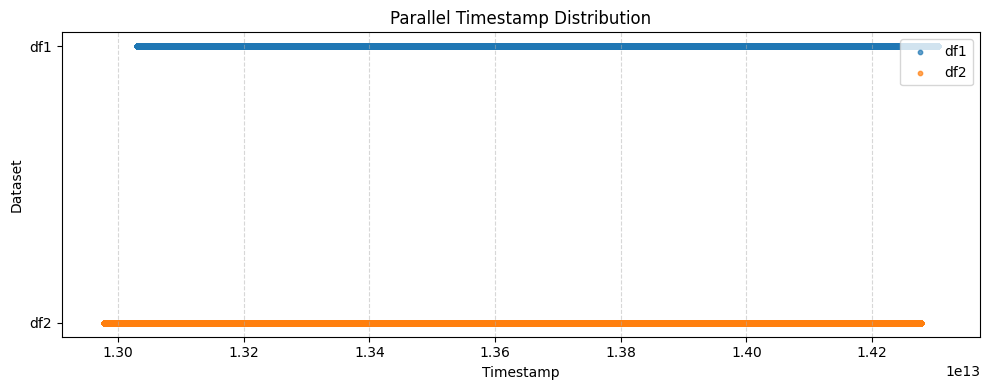

In [7]:
#plot_timestamp_distribution_parallel
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

def plot_timestamp_distribution_parallel(df1, df2, time_col="timestamp", label1="df1", label2="df2"):
    """
    Plot two timestamp distributions in parallel (non-overlapping) rows.
    X-axis: timestamp values
    Y-axis: fixed levels to separate datasets visually.
    """

    plt.figure(figsize=(10, 4))

    # fixed y-levels for visual separation
    y1 = [1] * len(df1)
    y2 = [0] * len(df2)

    plt.scatter(df1[time_col], y1, label=label1, alpha=0.7, s=10)
    plt.scatter(df2[time_col], y2, label=label2, alpha=0.7, s=10)

    plt.yticks([0, 1], [label2, label1])
    plt.xlabel("Timestamp")
    plt.ylabel("Dataset")
    plt.title("Parallel Timestamp Distribution")
    plt.grid(True, axis="x", linestyle="--", alpha=0.5)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

plot_timestamp_distribution_parallel(corrected_df, df_rapl_watt)

1000135.4239307375
0          NaN
1     974756.0
2    1038924.0
3     931747.0
4    1005370.0
Name: timestamp, dtype: float64
1000135.4239307375
    index       timestamp  energy_pkg  energy_dram  energy_psys    energy  \
2       3  12977091622342    0.004272     0.000916          0.0  0.004272   
4       5  12977093559459    0.004028     0.000854          0.0  0.004028   
5       6  12977094569945    0.004150     0.000916          0.0  0.004150   
7       8  12977096612605    0.004028     0.001038          0.0  0.004028   
10     11  12977099530762    0.004761     0.000977          0.0  0.004761   

       power  dram_rapl    ts_diff  
2   4.112390   0.881226  1038924.0  
4   4.006804   0.849928  1005370.0  
5   4.107321   0.906027  1010486.0  
7   3.702432   0.953657  1088020.0  
10  4.758039   0.976008  1000568.0  


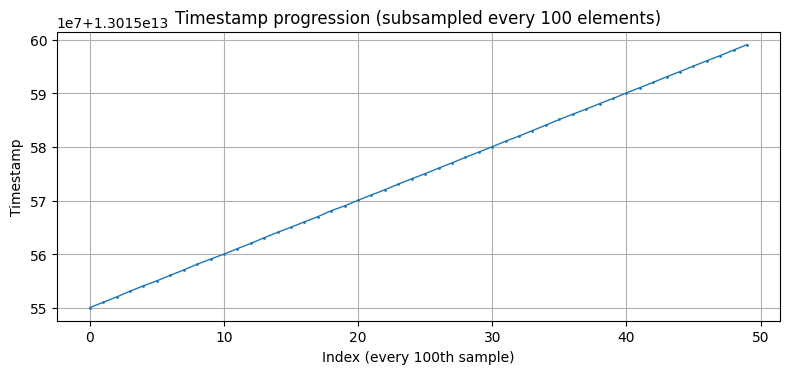

In [9]:
print(df_rapl_watt["timestamp"].diff().dropna().mean())

df_time_explore = df_rapl_watt.reset_index(names="index")
diff_mean = df_time_explore["timestamp"].diff().dropna().mean()
print(df_time_explore["timestamp"].diff().head())
print(diff_mean)
df_time_explore["ts_diff"] = df_time_explore["timestamp"].diff()
outliers = df_time_explore[df_time_explore["ts_diff"] > diff_mean]
print(outliers.head())

ts_sub_1 = df_rapl_watt["timestamp"].iloc[38450:38500].reset_index(drop=True)
# Plot timestamp vs index
plt.figure(figsize=(8, 4))
plt.plot(ts_sub_1.index, ts_sub_1, marker='o', linestyle='-', linewidth=1, markersize=1)

plt.xlabel("Index (every 100th sample)")
plt.ylabel("Timestamp")
plt.title("Timestamp progression (subsampled every 100 elements)")
plt.grid(True)
plt.tight_layout()
plt.show()



In [115]:
import pandas as pd
import numpy as np

def merge_by_bracketing_average(df1, df2, time_col="timestamp", t=500_000, suffix="_2"):
    """
    Bracket-merge df1 with df2 using integer timestamp arithmetic only.
    """

    # Sort
    df1 = df1.sort_values(time_col).reset_index(drop=True)
    df2 = df2.sort_values(time_col).reset_index(drop=True)

    t1 = df1[time_col].to_numpy(np.int64)
    t2 = df2[time_col].to_numpy(np.int64)

    # Get nearest right index in df2
    idx_right = np.searchsorted(t2, t1, side="left")
    idx_left = idx_right - 1

    # Clip to valid range inside df2
    idx_left = np.clip(idx_left, 0, len(t2) - 1)
    idx_right = np.clip(idx_right, 0, len(t2) - 1)

    # Gather timestamps
    t_left  = t2[idx_left]
    t_right = t2[idx_right]

    # Integer differences
    diff_left  = np.abs(t1 - t_left)
    diff_right = np.abs(t1 - t_right)

    # Require that left < t1 < right AND both within tolerance
    valid = (
        (diff_left <= t) &
        (diff_right <= t) &
        (t_left <= t1) &
        (t_right >= t1) &
        (idx_left != idx_right)
    )

    if not valid.any():
        return df1.iloc[0:0]   # empty

    # Filter indices
    df1_valid = df1[valid].reset_index(drop=True)
    left_idx  = idx_left[valid]
    right_idx = idx_right[valid]

    left_df2  = df2.iloc[left_idx].reset_index(drop=True)
    right_df2 = df2.iloc[right_idx].reset_index(drop=True)

    # Integer midpoint timestamp
    # (safe: stays int64)
    merged_time = (left_df2[time_col].to_numpy(np.int64)
                   + right_df2[time_col].to_numpy(np.int64)) // 2

    # Average only numeric columns, integer arithmetic
    df2_avg = left_df2.copy()
    numeric_cols = df2_avg.select_dtypes(include=[np.number]).columns

    for c in numeric_cols:
        df2_avg[c] = (left_df2[c].to_numpy(np.int64)
                      + right_df2[c].to_numpy(np.int64)) // 2

    # Write midpoint timestamp to separate column
    df2_avg[time_col + suffix] = merged_time

    # Merge side-by-side
    merged = pd.concat(
        [df1_valid.reset_index(drop=True),
         df2_avg.add_suffix(suffix)],
        axis=1
    )

    # Integer difference
    merged["timestamp_diff"] = (
        merged[time_col + suffix] - merged[time_col]
    ).astype(np.int64)

    return merged

df_rapl_watt["timestamp_1"] = df_rapl_watt["timestamp"]
corrected_df["timestamp_2"] = corrected_df["timestamp"]

print(df_rapl_watt.shape)
rapl_teensy_merged = merge_by_bracketing_average(df1=df_rapl_watt, df2=corrected_df, time_col="timestamp", t=500000, suffix="_2")
print(rapl_teensy_merged.shape)

rapl_teensy_merged["cpu_total"] = (rapl_teensy_merged["Y_2"].astype("float32") + rapl_teensy_merged["Z_2"].astype("float32")).astype("float32")
rapl_teensy_merged["abs_total"] = (rapl_teensy_merged["A_2"]+rapl_teensy_merged["B_2"]+rapl_teensy_merged["C_2"]+rapl_teensy_merged["D_2"]+rapl_teensy_merged["H_2"]+rapl_teensy_merged["I_2"]+rapl_teensy_merged["J_2"]+rapl_teensy_merged["K_2"]+rapl_teensy_merged["Y_2"]+rapl_teensy_merged["Z_2"]+rapl_teensy_merged["O_2"]+rapl_teensy_merged["P_2"]+rapl_teensy_merged["Q_2"]+rapl_teensy_merged["R_2"]+rapl_teensy_merged["U_2"]+rapl_teensy_merged["V_2"])
rapl_teensy_merged.head(3)

(1299869, 8)
(1153470, 27)


,timestamp,energy_pkg,energy_dram,energy_psys,energy,power,dram_rapl,timestamp_1,timestamp_2,A_2,...,O_2,P_2,Q_2,R_2,U_2,V_2,timestamp_2_2,timestamp_diff,cpu_total,abs_total
0,13030526466517,0.003784,0.000916,0.0,0.003784,3.723608,0.900873,13030526466517,13030526252933,1,...,0,1,2,1,5,1,13030526252933,-213584,8.0,21
1,13030527482485,0.003662,0.000854,0.0,0.003662,3.604552,0.841062,13030527482485,13030527290141,1,...,0,1,2,1,5,1,13030527290141,-192344,8.0,21
2,13030528417760,0.004211,0.000916,0.0,0.004211,4.502874,0.978886,13030528417760,13030528327329,1,...,0,1,2,1,5,1,13030528327329,-90431,8.0,21


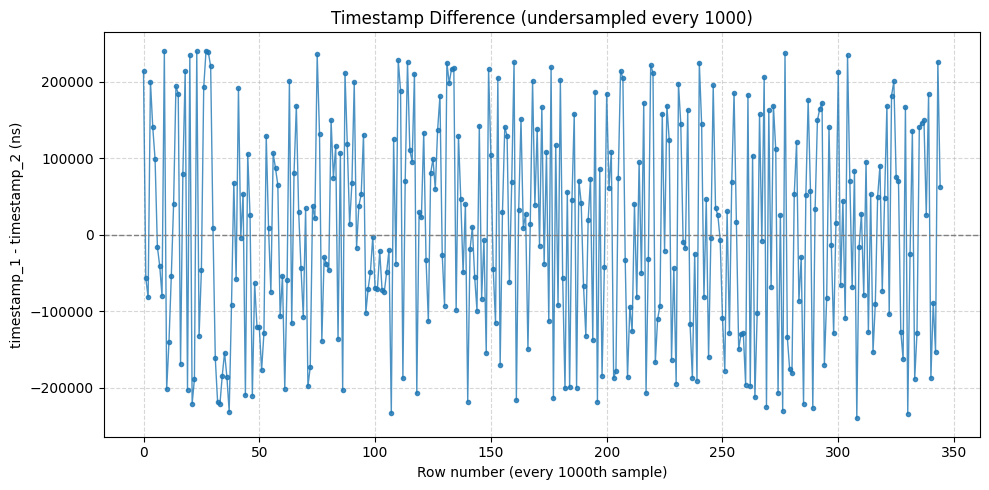

In [11]:
import matplotlib.pyplot as plt

def plot_timestamp_difference_undersampled(
    merged_df, ts1_col="timestamp_1", ts2_col="timestamp_2", step=1000, title=None
):
    """
    Plot undersampled difference between two timestamp columns,
    using row number as the X-axis.

    Parameters
    ----------
    merged_df : pd.DataFrame
        DataFrame containing both timestamp columns.
    ts1_col : str
        Column name for the left (master) timestamp.
    ts2_col : str
        Column name for the right (aligned) timestamp.
    step : int, default 100
        Sampling step size (take every nth row).
    title : str, optional
        Custom plot title.
    """

    # undersample
    df_sub = merged_df.iloc[0:345000].iloc[::step].copy()

    # compute difference
    diff = df_sub[ts1_col] - df_sub[ts2_col]
    diff = diff.replace([np.inf, -np.inf], np.nan)

    # x-axis as row number
    x = np.arange(len(df_sub))

    plt.figure(figsize=(10, 5))
    plt.plot(x, diff, marker=".", linestyle="-", linewidth=1, alpha=0.8)
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)

    plt.xlabel(f"Row number (every {step}th sample)")
    plt.ylabel(f"{ts1_col} - {ts2_col} (ns)")
    plt.title(title or f"Timestamp Difference (undersampled every {step})")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_timestamp_difference_undersampled(rapl_teensy_merged, ts1_col="timestamp_1", ts2_col="timestamp_2")

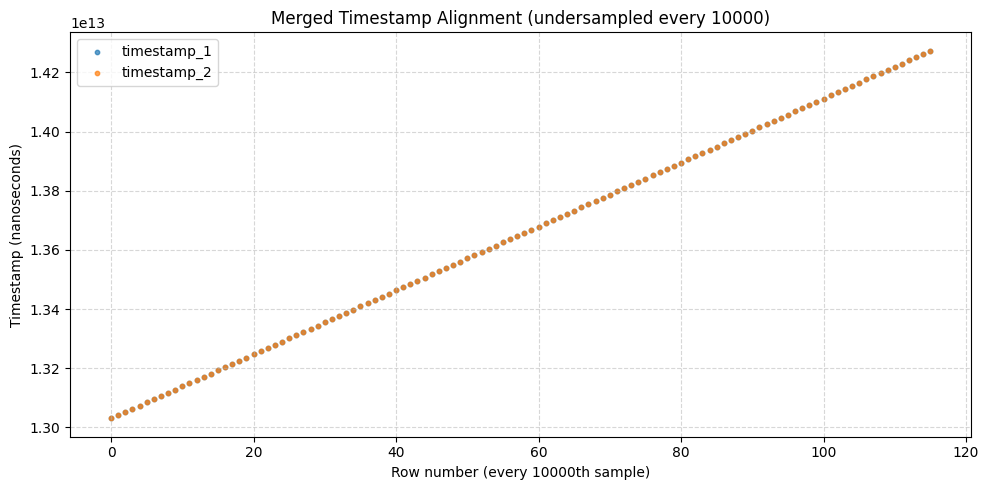

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_merged_timestamps_undersampled(
    merged_df, ts1_col="timestamp_1", ts2_col="timestamp_2", step=10000, title=None
):
    """
    Plot both merged timestamp columns vs. row number, undersampled, using dots instead of lines.

    Parameters
    ----------
    merged_df : pd.DataFrame
        DataFrame after merge_asof() containing both timestamp columns.
    ts1_col : str
        Column name for the left (master) timestamp.
    ts2_col : str
        Column name for the right (aligned) timestamp.
    step : int, default 100
        Sampling step size (take every nth row).
    title : str, optional
        Optional title for the plot.
    """

    # undersample
    df_sub = merged_df.iloc[::step].copy()
    x = np.arange(len(df_sub))

    plt.figure(figsize=(10, 5))
    plt.scatter(x, df_sub[ts1_col], label=ts1_col, s=10, alpha=0.7)
    plt.scatter(x, df_sub[ts2_col], label=ts2_col, s=10, alpha=0.7)

    plt.xlabel(f"Row number (every {step}th sample)")
    plt.ylabel("Timestamp (nanoseconds)")
    plt.title(title or f"Merged Timestamp Alignment (undersampled every {step})")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_merged_timestamps_undersampled(rapl_teensy_merged, ts1_col="timestamp_1", ts2_col="timestamp_2")

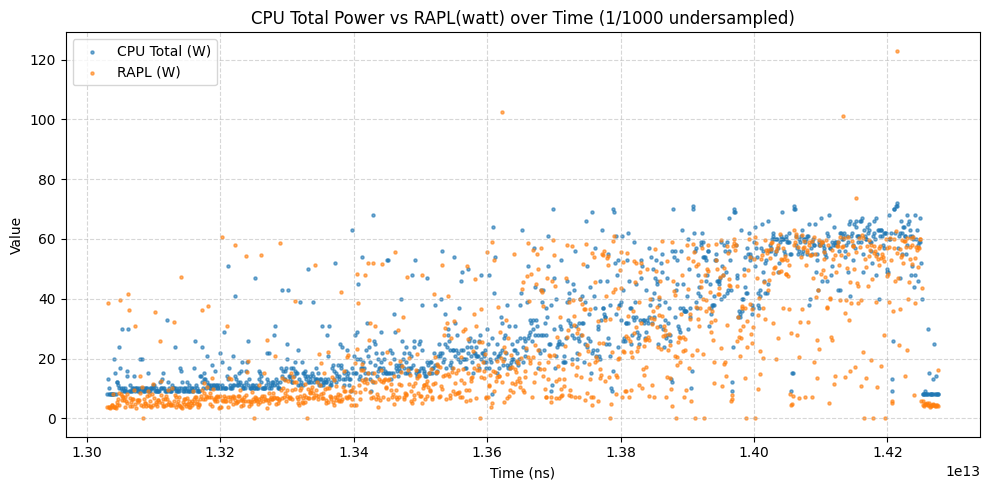

In [116]:
import matplotlib.pyplot as plt

def plot_cpu_vs_energy(df, time_col="timestamp", cpu_col="cpu_total", energy_col="power", sample_factor=1000):
    """
    Plot CPU total power and energy over time with small points and different colors,
    undersampling for performance.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing timestamp, cpu_total, and energy columns.
    time_col : str
        Name of the timestamp column (x-axis).
    cpu_col : str
        Name of the CPU total column (y-axis, one color).
    energy_col : str
        Name of the energy column (y-axis, another color).
    sample_factor : int, default 100
        Plot every Nth row for undersampling.
    """
    # Undersample
    df_sub = df.iloc[::sample_factor, :]

    plt.figure(figsize=(10, 5))
    plt.scatter(df_sub[time_col], df_sub[cpu_col], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
    plt.scatter(df_sub[time_col], df_sub[energy_col], s=5, color='tab:orange', alpha=0.6, label="RAPL (W)")

    plt.xlabel("Time (ns)")
    plt.ylabel("Value")
    plt.title(f"CPU Total Power vs RAPL(watt) over Time (1/{sample_factor} undersampled)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_cpu_vs_energy(rapl_teensy_merged)

7
85
(364, 867)
349
81
0.875
0.6
15.200000000000001
5.5


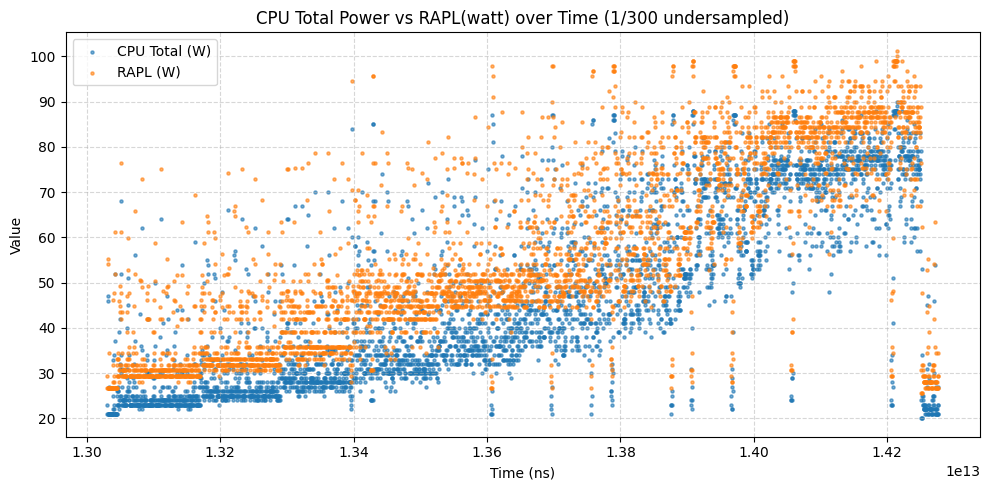

In [123]:
# this section calculates power coverage. 
# for each measurement, minor and major rail power split is used to derive the efficiency factor, which is then used to calculate the PSU efficiency cost
minor_rails = ["I_2", "J_2", "A_2", "B_2", "C_2", "D_2", "V_2"]
major_rails = ["H_2", "K_2", "O_2", "P_2", "Q_2", "R_2", "U_2", "Y_2", "Z_2"]
rapl_teensy_merged["minor_rails_total"] = rapl_teensy_merged[minor_rails].sum(axis=1)
rapl_teensy_merged["major_rails_total"] = rapl_teensy_merged[major_rails].sum(axis=1)

print(rapl_teensy_merged["minor_rails_total"].max())
print(rapl_teensy_merged["major_rails_total"].max())

#load modifiers 
# something to note about images: the top is actually Y = 0, so images are all backwards in terms of the Y value. Do not forget this during processing.
modifier_path = "C:/Users/andyh/Downloads/serialreceive/adjustmentFactor/modifier.npy"
modifier_array = np.load(modifier_path)
MAX_X_VAL = 900
MAX_Y_VAL = 160
print(modifier_array.shape)
max_x = modifier_array.shape[1]
max_y = modifier_array.shape[0]


coverage_preprocessing = pd.DataFrame()
coverage_preprocessing["minor_rails_y"] = max_y - (rapl_teensy_merged["minor_rails_total"] / MAX_Y_VAL * max_y).astype(int) # again this is because in images Y = 0 is the top
coverage_preprocessing["major_rails_x"] = (rapl_teensy_merged["major_rails_total"] / MAX_X_VAL * max_x).astype(int)
print(coverage_preprocessing["minor_rails_y"].min())
print(coverage_preprocessing["major_rails_x"].max())

ix = coverage_preprocessing["major_rails_x"].to_numpy()
iy = coverage_preprocessing["minor_rails_y"].to_numpy()

rapl_teensy_merged["psu_multiplier"] = modifier_array[iy, ix]
print(rapl_teensy_merged["psu_multiplier"].max())
print(rapl_teensy_merged["psu_multiplier"].min())

rapl_teensy_merged["psu_watt"] = rapl_teensy_merged["abs_total"] * (1 - rapl_teensy_merged["psu_multiplier"])
rapl_teensy_merged["psu_adjusted_total"] = rapl_teensy_merged["abs_total"] + rapl_teensy_merged["psu_watt"]
print(rapl_teensy_merged["psu_watt"].max())
print(rapl_teensy_merged["psu_watt"].min())

temp_df_for_display = pd.DataFrame()
temp_df_for_display["adjusted_total"] = rapl_teensy_merged["abs_total"] + rapl_teensy_merged["psu_watt"]
temp_df_for_display["abs_total"] = rapl_teensy_merged["abs_total"]
temp_df_for_display["timestamp"] = rapl_teensy_merged["timestamp"]
plot_cpu_vs_energy(temp_df_for_display, cpu_col="abs_total", energy_col="adjusted_total", sample_factor=300)





In [124]:
print(rapl_teensy_merged.columns)
mean_cpu = rapl_teensy_merged["cpu_total"].mean()
mean_power = rapl_teensy_merged["power"].mean()

print("Mean CPU total:", mean_cpu)
print("Mean Power:", mean_power)

def trapezoid (df, col= "cpu_total"): 

    # time differences (seconds)
    dt = df["timestamp"].diff() / 1e9
    df["timestamp_s"] = df["timestamp"] / 1e9

    # trapezoid: average power * time
    #energy_joules = ((df[col][:-1].values + df[col][1:].values) / 2 * dt[1:].values).sum() #naive trapezoid 
    energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid

    # convert to kWh
    energy_kwh = energy_joules / 3_600_000

    print(col)
    print("Energy (J):", energy_joules)
    print("Energy (kWh):", energy_kwh)
    return energy_kwh

#print(f"sum ={rapl_teensy_merged["energy"].sum()}")


kwh1 = trapezoid(rapl_teensy_merged, col= "cpu_total")
kwh2 = trapezoid(rapl_teensy_merged, col= "power")
print(kwh1/kwh2)

# kwh1 = trapezoid(rapl_teensy_running_average, col= "cpu_total_runningavg")
# kwh2 = trapezoid(rapl_teensy_running_average, col= "power_runningavg")
# print(kwh1/kwh2)

# kwh1 = trapezoid(rapl_teensy_running_average, col= "cpu_total_sg")
# kwh2 = trapezoid(rapl_teensy_running_average, col= "power_sg")
# print(kwh1/kwh2)

# kwh1 = trapezoid(rapl_teensy_running_average, col= "cpu_total_bw")
# kwh2 = trapezoid(rapl_teensy_running_average, col= "power_bw")
# print(kwh1/kwh2)



Index(['timestamp', 'energy_pkg', 'energy_dram', 'energy_psys', 'energy',
       'power', 'dram_rapl', 'timestamp_1', 'timestamp_2', 'A_2', 'B_2', 'C_2',
       'D_2', 'H_2', 'I_2', 'J_2', 'K_2', 'Y_2', 'Z_2', 'O_2', 'P_2', 'Q_2',
       'R_2', 'U_2', 'V_2', 'timestamp_2_2', 'timestamp_diff', 'cpu_total',
       'abs_total', 'timestamp_s', 'minor_rails_total', 'major_rails_total',
       'psu_multiplier', 'psu_watt', 'psu_adjusted_total'],
      dtype='object')
Mean CPU total: 31.377024
Mean Power: 24.49803
cpu_total
Energy (J): 39110.15814891286
Energy (kWh): 0.01086393281914246
power
Energy (J): 30542.44663320004
Energy (kWh): 0.008484012953666678
1.2805181791297493


C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3098274745.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid


In [125]:
import pandas as pd
import numpy as np

def split_df_into_time_buckets(df, time_col, n_buckets):
    """
    Split a DataFrame into n time buckets and return a list of sub-DataFrames.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing a time column.
    time_col : str
        Name of the timestamp column.
    n_buckets : int
        Number of time buckets.

    Returns
    -------
    buckets : list of pd.DataFrame
        List of sub-DataFrames, one per bucket. Empty buckets are skipped.
    """

    # Ensure time column is datetime or numeric
    ts = pd.to_datetime(df[time_col])

    # Bucket boundaries
    start = ts.min()
    end   = ts.max()

    edges = pd.date_range(start=start, end=end, periods=n_buckets+1)

    # Build list of DataFrames
    buckets = []

    for i in range(n_buckets):
        mask = (ts >= edges[i]) & (ts < edges[i+1])

        bucket_df = df.loc[mask]
        if not bucket_df.empty:
            buckets.append(bucket_df)

    return buckets

In [165]:
# plothelper def plot_columns(df, columns, x_col=None, title=None, xlabel=None, ylabel=None, figsize=(10, 5), style='-', markersize=2, alpha=0.9, legend=True):
import matplotlib.pyplot as plt

def plot_columns(df, columns, x_col=None, title=None, xlabel=None, ylabel=None,
                 figsize=(10, 5), style='-', markersize=2, alpha=0.9, legend=True):
    """
    Plot one or more DataFrame columns using matplotlib.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame containing the data.
    columns : list of str
        List of column names to plot.
    x_col : str, optional
        Column name to use as the x-axis. If None, use the DataFrame index.
    title : str, optional
        Plot title.
    xlabel, ylabel : str, optional
        Axis labels.
    figsize : tuple, optional
        Figure size.
    style : str, optional
        Line style (default: '-').
    markersize : int, optional
        Marker size (default: 2).
    alpha : float, optional
        Line transparency (default: 0.9).
    legend : bool, optional
        Whether to show a legend.

    Returns
    -------
    matplotlib.axes.Axes
        The plot’s axes object.
    """
    plt.figure(figsize=figsize)

    # Choose x-axis
    x = df[x_col] if x_col else df.index

    for col in columns:
        if col not in df.columns:
            print(f"⚠️ Column '{col}' not found, skipping.")
            continue
        if col == x_col:
            continue
        if (col=="CPU_RAPL" or col=="DRAM_RAPL"):
            style="--"

        plt.plot(x, df[col], style, label=col, markersize=markersize, alpha=alpha)

    plt.title(title or "Data Plot")
    plt.xlabel(xlabel or (x_col if x_col else "Index"))
    plt.ylabel(ylabel or "Value")

    if legend:
        plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return

In [155]:
num_buckets = 60
data_by_time_bucket = split_df_into_time_buckets(rapl_teensy_merged, "timestamp", num_buckets)
trapezoid_result = pd.DataFrame(index = range(num_buckets))
trapezoid_result['ALL'] = np.zeros(num_buckets)
trapezoid_result['NIC'] = np.zeros(num_buckets)
trapezoid_result['DRAM'] = np.zeros(num_buckets)
trapezoid_result['CPU'] = np.zeros(num_buckets)
trapezoid_result['DISK'] = np.zeros(num_buckets)
trapezoid_result['MAIN'] = np.zeros(num_buckets)
trapezoid_result['CPU_RAPL'] = np.zeros(num_buckets)
trapezoid_result['DRAM_RAPL'] = np.zeros(num_buckets)
trapezoid_result['PSU_ADJUSTED_TOTAL'] = np.zeros(num_buckets)
trapezoid_result['PSU'] = np.zeros(num_buckets)


index = 0
for bucket in data_by_time_bucket:
    
    
    bucket['NIC'] = bucket['I_2']
    bucket['DRAM'] = bucket['P_2'] + bucket['Q_2'] + bucket['R_2'] + bucket['A_2'] + bucket['C_2']
    # bucket['cpu_total']
    bucket['DISK'] = bucket['U_2'] + bucket['V_2']
    trapezoid_result["ALL"][index] = trapezoid(bucket, col='abs_total')
    trapezoid_result["NIC"][index]  = trapezoid(bucket, col='NIC')
    trapezoid_result["DRAM"][index]  = trapezoid(bucket, col='DRAM')
    trapezoid_result["CPU"][index]  = trapezoid(bucket, col='cpu_total')
    trapezoid_result["DISK"][index]  = trapezoid(bucket, col='DISK')
    trapezoid_result["MAIN"][index] = trapezoid(bucket, col='abs_total') - trapezoid(bucket, col='NIC') - trapezoid(bucket, col='DRAM') - trapezoid(bucket, col='cpu_total') - trapezoid(bucket, col='DISK')
    trapezoid_result["CPU_RAPL"][index]  = trapezoid(bucket, col='power')    
    trapezoid_result["DRAM_RAPL"][index]  = trapezoid(bucket, col='dram_rapl')
    trapezoid_result['PSU_ADJUSTED_TOTAL'][index] = trapezoid(bucket, col='psu_watt') + trapezoid(bucket, col='abs_total')
    trapezoid_result['PSU'][index] = trapezoid(bucket,col="psu_watt")
    index += 1

# stack these together for plotting
stacking_series = ["PSU", "NIC", "DISK", "DRAM", "CPU"] # main is removed because the ratio is so small.
trapezoid_result_stacked = pd.DataFrame()

for index in range(0, len(stacking_series)):
    trapezoid_result_stacked[stacking_series[index]] = trapezoid_result[stacking_series[index]]
    for r_index in range(0, index):
        trapezoid_result_stacked[stacking_series[index]] = trapezoid_result_stacked[stacking_series[index]] + trapezoid_result[stacking_series[r_index]]
trapezoid_result_stacked["index"] = range(len(trapezoid_result_stacked))    

trapezoid_result_stacked["CPU_RAPL"] = trapezoid_result["CPU_RAPL"]
trapezoid_result_stacked["CPU_RAPL"] = trapezoid_result_stacked["CPU_RAPL"] + trapezoid_result_stacked[stacking_series[3]]
trapezoid_result_stacked["DRAM_RAPL"] = trapezoid_result["DRAM_RAPL"]
trapezoid_result_stacked["DRAM_RAPL"] = trapezoid_result_stacked["DRAM_RAPL"] + trapezoid_result_stacked[stacking_series[2]]
#trapezoid_result_stacked["PSU_ADJUSTED_TOTAL"] = trapezoid_result['PSU_ADJUSTED_TOTAL']



C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3631793520.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bucket['NIC'] = bucket['I_2']
C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3631793520.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bucket['DRAM'] = bucket['P_2'] + bucket['Q_2'] + bucket['R_2'] + bucket['A_2'] + bucket['C_2']
C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3631793520.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

abs_total
Energy (J): 527.9583360910055
Energy (kWh): 0.00014665509335861265
NIC
Energy (J): 41.55232040999908
Energy (kWh): 1.1542311224999745e-05
DRAM
Energy (J): 117.5659629515003
Energy (kWh): 3.2657211930972306e-05
cpu_total
Energy (J): 243.89820624650838
Energy (kWh): 6.774950173514122e-05
DISK
Energy (J): 124.94184648299779
Energy (kWh): 3.4706068467499387e-05
abs_total
Energy (J): 527.9583360910055
Energy (kWh): 0.00014665509335861265
NIC
Energy (J): 41.55232040999908
Energy (kWh): 1.1542311224999745e-05
DRAM
Energy (J): 117.5659629515003
Energy (kWh): 3.2657211930972306e-05
cpu_total
Energy (J): 243.89820624650838
Energy (kWh): 6.774950173514122e-05
DISK
Energy (J): 124.94184648299779
Energy (kWh): 3.4706068467499387e-05
power
Energy (J): 155.34003761280917
Energy (kWh): 4.315001044800255e-05
dram_rapl
Energy (J): 22.73368151520705
Energy (kWh): 6.3149115320019585e-06
psu_watt
Energy (J): 143.4082866524282
Energy (kWh): 3.983563518123005e-05
abs_total
Energy (J): 527.958336091

C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3098274745.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["timestamp_s"] = df["timestamp"] / 1e9
C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3098274745.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid
C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3631793520.py:25: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas

NIC
Energy (J): 42.11267544000111
Energy (kWh): 1.169796540000031e-05
DRAM
Energy (J): 143.70564660450873
Energy (kWh): 3.9918235167919094e-05
cpu_total
Energy (J): 332.59753349649145
Energy (kWh): 9.23882037490254e-05
DISK
Energy (J): 125.75842595550694
Energy (kWh): 3.493289609875193e-05
abs_total
Energy (J): 644.1742814965082
Energy (kWh): 0.00017893730041569674
NIC
Energy (J): 42.11267544000111
Energy (kWh): 1.169796540000031e-05
DRAM
Energy (J): 143.70564660450873
Energy (kWh): 3.9918235167919094e-05
cpu_total
Energy (J): 332.59753349649145
Energy (kWh): 9.23882037490254e-05
DISK
Energy (J): 125.75842595550694
Energy (kWh): 3.493289609875193e-05
power
Energy (J): 232.5182512104936
Energy (kWh): 6.458840311402599e-05
dram_rapl
Energy (J): 30.864384680634174
Energy (kWh): 8.573440189065048e-06
psu_watt
Energy (J): 183.98198910800858
Energy (kWh): 5.110610808555794e-05
abs_total
Energy (J): 644.1742814965082
Energy (kWh): 0.00017893730041569674
psu_watt
Energy (J): 183.98198910800858

C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3098274745.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["timestamp_s"] = df["timestamp"] / 1e9
C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3098274745.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid
C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3631793520.py:25: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas

NIC
Energy (J): 42.11224544450124
Energy (kWh): 1.16978459568059e-05
DRAM
Energy (J): 146.59636536450034
Energy (kWh): 4.0721212601250093e-05
cpu_total
Energy (J): 527.8750450224961
Energy (kWh): 0.00014663195695069337
DISK
Energy (J): 124.6505500860003
Energy (kWh): 3.462515280166675e-05
abs_total
Energy (J): 841.234205917498
Energy (kWh): 0.0002336761683104161
NIC
Energy (J): 42.11224544450124
Energy (kWh): 1.16978459568059e-05
DRAM
Energy (J): 146.59636536450034
Energy (kWh): 4.0721212601250093e-05
cpu_total
Energy (J): 527.8750450224961
Energy (kWh): 0.00014663195695069337
DISK
Energy (J): 124.6505500860003
Energy (kWh): 3.462515280166675e-05
power
Energy (J): 396.73682505772206
Energy (kWh): 0.00011020467362714502
dram_rapl
Energy (J): 35.265943631787934
Energy (kWh): 9.796095453274426e-06
psu_watt
Energy (J): 227.302773970172
Energy (kWh): 6.31396594361589e-05
abs_total
Energy (J): 841.234205917498
Energy (kWh): 0.0002336761683104161
psu_watt
Energy (J): 227.302773970172
Energy (

C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3098274745.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["timestamp_s"] = df["timestamp"] / 1e9
C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3098274745.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid
C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3631793520.py:24: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas

abs_total
Energy (J): 1161.332191609028
Energy (kWh): 0.00032259227544695227
NIC
Energy (J): 41.54984822999904
Energy (kWh): 1.1541624508333068e-05
DRAM
Energy (J): 158.2993569559967
Energy (kWh): 4.3972043598887974e-05
cpu_total
Energy (J): 835.9776745760364
Energy (kWh): 0.00023221602071556567
DISK
Energy (J): 125.50531184699594
Energy (kWh): 3.486258662416554e-05
abs_total
Energy (J): 1161.332191609028
Energy (kWh): 0.00032259227544695227
NIC
Energy (J): 41.54984822999904
Energy (kWh): 1.1541624508333068e-05
DRAM
Energy (J): 158.2993569559967
Energy (kWh): 4.3972043598887974e-05
cpu_total
Energy (J): 835.9776745760364
Energy (kWh): 0.00023221602071556567
DISK
Energy (J): 125.50531184699594
Energy (kWh): 3.486258662416554e-05
power
Energy (J): 669.8005167714541
Energy (kWh): 0.0001860556991031817
dram_rapl
Energy (J): 40.28605630043026
Energy (kWh): 1.1190571194563961e-05
psu_watt
Energy (J): 187.95944858396905
Energy (kWh): 5.2210957939991406e-05
abs_total
Energy (J): 1161.332191609

C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3098274745.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["timestamp_s"] = df["timestamp"] / 1e9
C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3098274745.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid
C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3631793520.py:28: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas

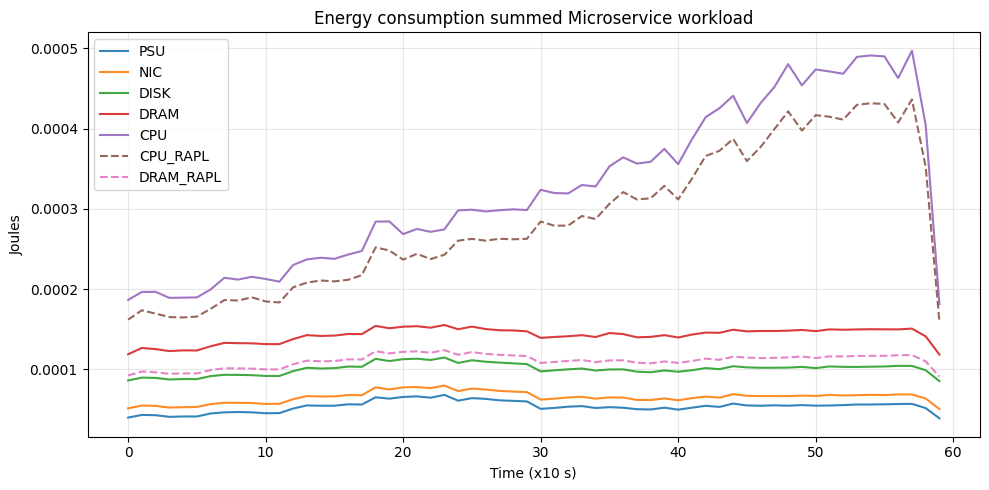

In [166]:
plot_columns(trapezoid_result_stacked, columns=trapezoid_result_stacked.columns , x_col="index", markersize=1, ylabel="Joules", xlabel="Time (x10 s)", title="Energy consumption summed Microservice workload")


In [148]:
# plothelper def plot_columns(df, columns, x_col=None, title=None, xlabel=None, ylabel=None, figsize=(10, 5), style='-', markersize=2, alpha=0.9, legend=True):
import matplotlib.pyplot as plt

def plot_columns_scatter(df, columns, x_col=None, title=None, xlabel=None, ylabel=None,
                 figsize=(10, 5), style='-', markersize=2, alpha=0.9, legend=True):
    """
    Plot one or more DataFrame columns using matplotlib.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame containing the data.
    columns : list of str
        List of column names to plot.
    x_col : str, optional
        Column name to use as the x-axis. If None, use the DataFrame index.
    title : str, optional
        Plot title.
    xlabel, ylabel : str, optional
        Axis labels.
    figsize : tuple, optional
        Figure size.
    style : str, optional
        Line style (default: '-').
    markersize : int, optional
        Marker size (default: 2).
    alpha : float, optional
        Line transparency (default: 0.9).
    legend : bool, optional
        Whether to show a legend.

    Returns
    -------
    matplotlib.axes.Axes
        The plot’s axes object.
    """
    plt.figure(figsize=figsize)

    # Choose x-axis
    x = df[x_col] if x_col else df.index

    for col in columns:
        if col not in df.columns:
            print(f"⚠️ Column '{col}' not found, skipping.")
            continue
        if col == x_col:
            continue
        plt.scatter(x, df[col], label=col, s=markersize, alpha=alpha)

    #plt.title(title or "Data Plot")
    #plt.xlabel(xlabel or (x_col if x_col else "index"))
    #plt.ylabel(ylabel or "Value")
    plt.title("RAPL measurement bias for increasing microservice workload")
    plt.xlabel("Time (S)")
    plt.ylabel("Sensor measurement (J) / RAPL measurement (J)")

    #if legend:
        #plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return

Index(['ALL', 'NIC', 'DRAM', 'CPU', 'DISK', 'MAIN', 'CPU_RAPL', 'DRAM_RAPL',
       'PSU_ADJUSTED_TOTAL', 'PSU', 'cpu_bias'],
      dtype='object')
Index(['ALL', 'NIC', 'DRAM', 'CPU', 'DISK', 'MAIN', 'CPU_RAPL', 'DRAM_RAPL',
       'PSU_ADJUSTED_TOTAL', 'PSU', 'cpu_bias'],
      dtype='object')


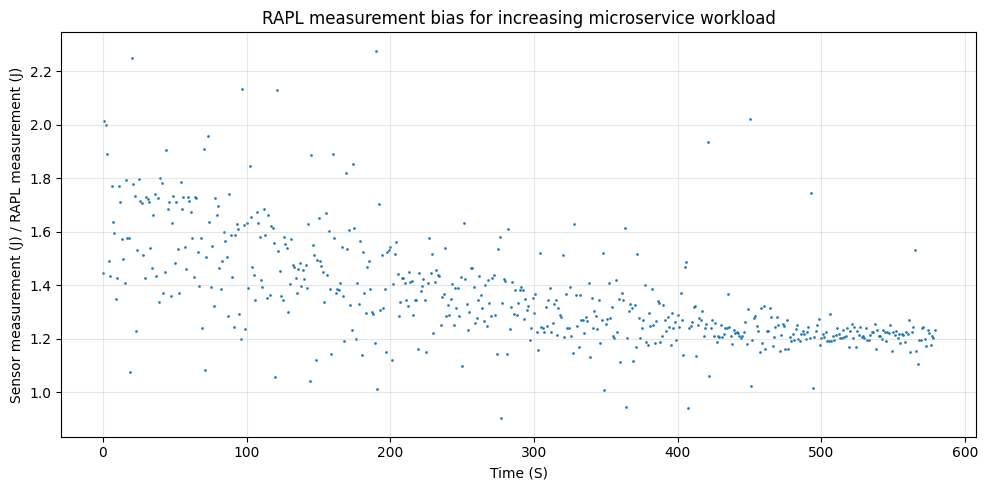

In [150]:
# explore bias per bucket 
print(trapezoid_result.columns)
trapezoid_result.reset_index()
print(trapezoid_result.columns)
trapezoid_result["cpu_bias"] = trapezoid_result["CPU"] / trapezoid_result["CPU_RAPL"]
plot_columns_scatter(trapezoid_result.iloc[:580], columns=["cpu_bias"], markersize=1, title="RAPL Measurement bias overtime") #workload ended @ 580s


In [84]:
rapl_teensy_merged['NIC'] = rapl_teensy_merged['I_2']
rapl_teensy_merged['DRAM'] = rapl_teensy_merged['P_2'] + rapl_teensy_merged['Q_2'] + rapl_teensy_merged['R_2'] + rapl_teensy_merged['A_2'] + rapl_teensy_merged['C_2']
# rapl_teensy_merged['cpu_total']
rapl_teensy_merged['DISK'] = rapl_teensy_merged['U_2'] + rapl_teensy_merged['V_2']

total_j = trapezoid(rapl_teensy_merged, col='psu_adjusted_total')

print(trapezoid(rapl_teensy_merged, col='NIC'))
print(trapezoid(rapl_teensy_merged, col='DRAM'))
print(trapezoid(rapl_teensy_merged, col='cpu_total'))
print(trapezoid(rapl_teensy_merged, col='DISK'))
print(trapezoid(rapl_teensy_merged, col='abs_total'))

mainboard_ratio = 1 - trapezoid(rapl_teensy_merged, col='psu_watt')/total_j - trapezoid(rapl_teensy_merged, col='cpu_total')/total_j - trapezoid(rapl_teensy_merged, col='DRAM')/total_j - trapezoid(rapl_teensy_merged, col='DISK')/total_j - trapezoid(rapl_teensy_merged, col='NIC')/total_j

rapl_unaccounted_ratio = 1 - trapezoid(rapl_teensy_merged, col='cpu_total')/total_j - trapezoid(rapl_teensy_merged, col='DRAM')/total_j

data_sensor = [
    ("CPU",   "#3E7695", trapezoid(rapl_teensy_merged, col='cpu_total')/total_j),
    ("DRAM",   "#E5D35E", trapezoid(rapl_teensy_merged, col='DRAM')/total_j),
    ("DISK", "#DD8A52", trapezoid(rapl_teensy_merged, col='DISK')/total_j),
    ("NIC",  "#C44E52", trapezoid(rapl_teensy_merged, col='NIC')/total_j),
    ("Mainboard","#255430", mainboard_ratio ),
    ("PSU", "#32CD32", trapezoid(rapl_teensy_merged, col='psu_watt')/total_j )
]

data_rapl = [
    ("RAPL_PKG",   "#3E7695", trapezoid(rapl_teensy_merged, col='power')/total_j),
    ("RAPL_PKG underestimation",   "#696969", trapezoid(rapl_teensy_merged, col='cpu_total')/total_j - trapezoid(rapl_teensy_merged, col='power')/total_j),
    ("RAPL_DRAM",   "#E5D35E", trapezoid(rapl_teensy_merged, col='dram_rapl')/total_j),
    ("RAPL_DRAM underestimation",   "#a1a1a1", trapezoid(rapl_teensy_merged, col='DRAM')/total_j - trapezoid(rapl_teensy_merged, col='dram_rapl')/total_j ),
    ("DISK", "#969696", trapezoid(rapl_teensy_merged, col='DISK')/total_j),
    ("NIC",  "#8a8a8a", trapezoid(rapl_teensy_merged, col='NIC')/total_j),
    ("Mainboard","#3d3d3d", mainboard_ratio ),
    ("PSU", "#808080", trapezoid(rapl_teensy_merged, col='psu_watt')/total_j )
]

data_rapl_legend = [
    ("RAPL_PKG",   "#3E7695", trapezoid(rapl_teensy_merged, col='power')/total_j),
    ("RAPL_DRAM",   "#E5D35E", trapezoid(rapl_teensy_merged, col='dram_rapl')/total_j),
    ("Unaccounted components", "#696969", rapl_unaccounted_ratio)
]

C:\Users\andyh\AppData\Local\Temp\ipykernel_6408\3098274745.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid


psu_adjusted_total
Energy (J): 69835.51006354137
Energy (kWh): 0.01939875279542816
NIC
Energy (J): 2542.4051360565018
Energy (kWh): 0.0007062236489045838
0.0007062236489045838
DRAM
Energy (J): 9022.991929354986
Energy (kWh): 0.0025063866470430517
0.0025063866470430517
cpu_total
Energy (J): 39110.15814891286
Energy (kWh): 0.01086393281914246
0.01086393281914246
DISK
Energy (J): 7588.230172976992
Energy (kWh): 0.0021078417147158313
0.0021078417147158313
abs_total
Energy (J): 58263.785387301345
Energy (kWh): 0.01618438482980593
0.01618438482980593
psu_watt
Energy (J): 11571.72467624003
Energy (kWh): 0.0032143679656222307
cpu_total
Energy (J): 39110.15814891286
Energy (kWh): 0.01086393281914246
DRAM
Energy (J): 9022.991929354986
Energy (kWh): 0.0025063866470430517
DISK
Energy (J): 7588.230172976992
Energy (kWh): 0.0021078417147158313
NIC
Energy (J): 2542.4051360565018
Energy (kWh): 0.0007062236489045838
cpu_total
Energy (J): 39110.15814891286
Energy (kWh): 0.01086393281914246
DRAM
Energy (

In [81]:
import matplotlib.pyplot as plt

def autopct_conditional(pct, threshold=5):
    return f"{pct:.1f}%" if pct >= threshold else ""

def plot_pie_from_tuples(data, filename=None, dpi=300, title="default_title"):
    """
    Plot a pie chart given a list of (name, color, value) tuples.

    Parameters
    ----------
    data : list of tuples
        Each tuple must be (label:str, color:str, value:float).
    filename : str or None
        If given, saves to file (pdf, png, svg depending on extension).
    dpi : int
        DPI only used for raster formats. Ignored for vector formats.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """

    labels  = [t[0] for t in data]
    colors  = [t[1] for t in data]
    values  = [t[2] for t in data]

    fig, ax = plt.subplots(figsize=(4,4))
    ax.set_title(title, pad=20)
    ax.pie(
        
        values,
        #labels=labels,
        colors=colors,
        autopct=lambda pct: autopct_conditional(pct, threshold=2),
        startangle=90,
        pctdistance=1.2,
    )
    ax.axis('equal')  # keep circular

    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=dpi)

    return fig, ax

(<Figure size 400x400 with 1 Axes>,
 <Axes: title={'center': 'RAPL Coverage in Microservice Workload'}>)

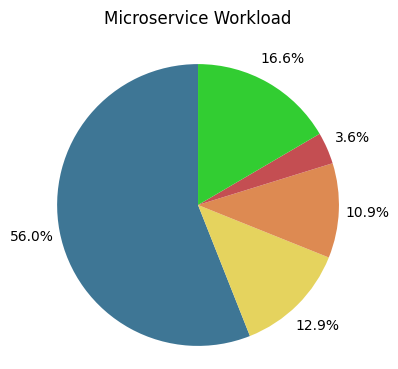

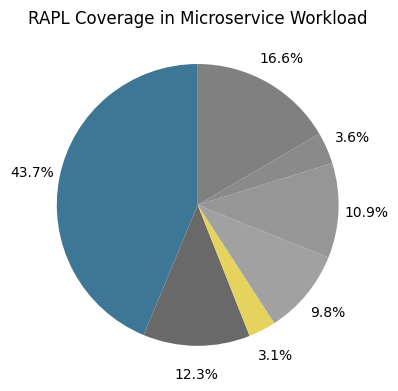

In [85]:
plot_pie_from_tuples(data_sensor, title="Microservice Workload", filename="pie_microservice.png")
plot_pie_from_tuples(data_rapl, title="RAPL Coverage in Microservice Workload", filename="pie_rapl_microservice.png")

In [86]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def legend_only(data, filename=None, ncol=1, fontsize=12):
    """
    Generate a legend-only figure.

    Parameters
    ----------
    data : list of tuples
        Each tuple must be (label, color) OR (label, color, value).
        Value is ignored.
    filename : str, optional
        If provided, saves the legend (pdf/png/svg).
    ncol : int
        Number of legend columns.
    fontsize : int
        Legend font size.

    Returns
    -------
    fig : Figure
    """

    # handle (label, color) and (label, color, value)
    labels = [t[0] for t in data]
    colors = [t[1] for t in data]

    # Create dummy handles
    handles = [Patch(facecolor=c, edgecolor='none') for c in colors]

    # Create figure with no axes
    fig = plt.figure(figsize=(3, 0.4*len(data)))
    
    legend = fig.legend(
        handles,
        labels,
        loc="center",
        frameon=False,
        ncol=ncol,
        fontsize=fontsize,
    )

    # Remove all padding around the figure
    plt.tight_layout(pad=0)

    if filename:
        fig.savefig(filename, bbox_inches="tight")

    return fig

legend_only(data_sensor, filename="legend.png")
legend_only(data_rapl_legend, filename="legend_rapl.png")

<Figure size 300x120 with 0 Axes>

<Figure size 300x240 with 0 Axes>

<Figure size 300x120 with 0 Axes>

C:\Users\andyh\AppData\Local\Temp\ipykernel_9980\1312169766.py:73: RuntimeWarning: invalid value encountered in log
  b, a = np.polyfit(x, np.log(y_pos), 1)
C:\Users\andyh\AppData\Local\Temp\ipykernel_9980\1312169766.py:98: RuntimeWarning: invalid value encountered in log
  b, a = np.polyfit(np.log(x_pos), np.log(y_pos), 1)
C:\Users\andyh\AppData\Local\Temp\ipykernel_9980\1312169766.py:144: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single

Best model: cubic
Parameters: [-6.41043587e-14  5.62495598e-11 -6.83640779e-09  2.72865134e-06]
R²: 0.4606515814000737
AIC: -16365.2975647102


C:\Users\andyh\AppData\Local\Temp\ipykernel_9980\1312169766.py:144: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trapezoid_result_stacked["bias_fit"][index] = np.pow(i, 3) * (-6.41043587e-14) + np.pow(i, 2) * 5.62495598e-11 + i * (-6.83640779e-09) + 2.72865134e-06
C:\Users\andyh\AppData\Local\Temp\ipykernel_9980\1312169766.py:144: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, 

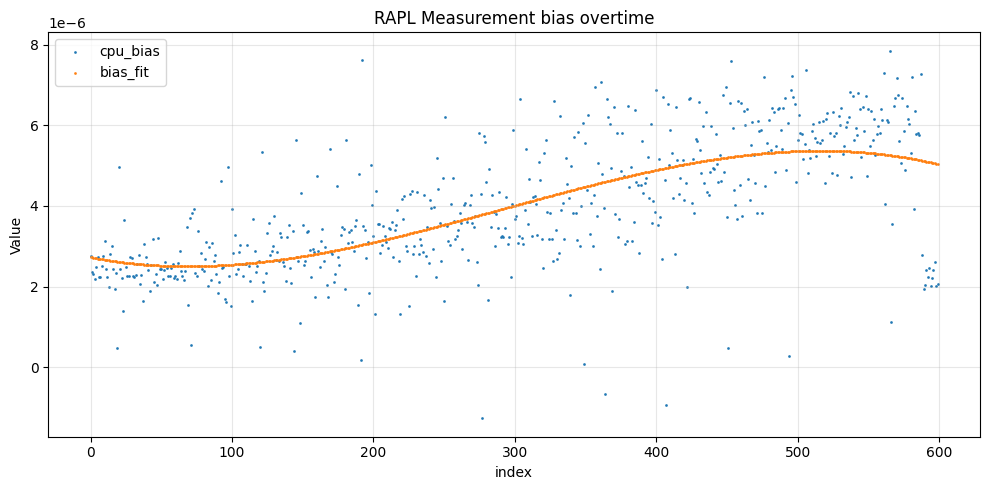

C:\Users\andyh\AppData\Local\Temp\ipykernel_9980\1312169766.py:73: RuntimeWarning: invalid value encountered in log
  b, a = np.polyfit(x, np.log(y_pos), 1)
C:\Users\andyh\AppData\Local\Temp\ipykernel_9980\1312169766.py:98: RuntimeWarning: invalid value encountered in log
  b, a = np.polyfit(np.log(x_pos), np.log(y_pos), 1)
C:\Users\andyh\AppData\Local\Temp\ipykernel_9980\1312169766.py:158: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trapezoid_result_stacked_increase["bias_fit"] = np.zeros(num_buckets_increase)
C:\Users\andyh\AppData\Local\Temp\ipykernel_9980\1312169766.py:161: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but

Best model: quadratic
Parameters: [5.84252408e-12 3.55195808e-09 2.29388323e-06]
R²: 0.5212542370506339
AIC: -15764.789075698107


C:\Users\andyh\AppData\Local\Temp\ipykernel_9980\1312169766.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trapezoid_result_stacked_increase["bias_fit"][index] = np.pow(i, 2) * (5.84252408e-12) + i * 3.55195808e-09 + 2.29388323e-06
C:\Users\andyh\AppData\Local\Temp\ipykernel_9980\1312169766.py:161: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexe

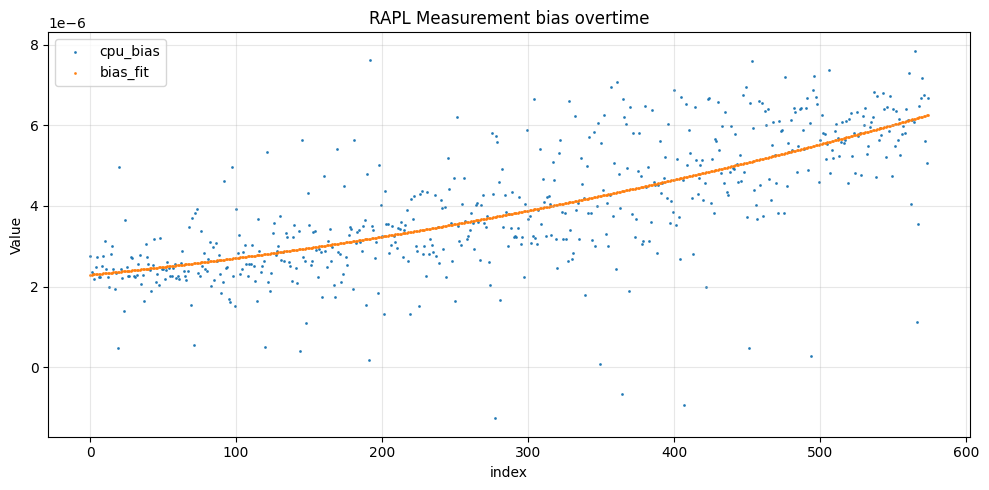

In [81]:
import numpy as np
from sklearn.metrics import r2_score
from dataclasses import dataclass

@dataclass
class FitResult:
    name: str
    params: np.ndarray
    y_pred: np.ndarray
    r2: float
    aic: float

def best_fit_model(x, y):
    """
    Determine the best type of function that fits the data.
    Tries several candidate models and compares using AIC.

    Models tested:
      - linear
      - quadratic
      - cubic
      - exponential
      - logarithmic
      - power law

    Parameters
    ----------
    x : array-like
    y : array-like

    Returns
    -------
    FitResult
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    
    # safeguard for positivity (needed for log and power)
    x_pos = x + 1e-12
    y_pos = y + 1e-12

    results = []

    # ---------- Linear ----------
    coeffs = np.polyfit(x, y, 1)
    y_pred = np.polyval(coeffs, x)
    rss = np.sum((y - y_pred)**2)
    k = len(coeffs)
    aic = 2*k + len(x)*np.log(rss/len(x))
    results.append(FitResult("linear", coeffs, y_pred, r2_score(y, y_pred), aic))

    # ---------- Quadratic ----------
    coeffs = np.polyfit(x, y, 2)
    y_pred = np.polyval(coeffs, x)
    rss = np.sum((y - y_pred)**2)
    k = len(coeffs)
    aic = 2*k + len(x)*np.log(rss/len(x))
    results.append(FitResult("quadratic", coeffs, y_pred, r2_score(y, y_pred), aic))

    # ---------- Cubic ----------
    coeffs = np.polyfit(x, y, 3)
    y_pred = np.polyval(coeffs, x)
    rss = np.sum((y - y_pred)**2)
    k = len(coeffs)
    aic = 2*k + len(x)*np.log(rss/len(x))
    results.append(FitResult("cubic", coeffs, y_pred, r2_score(y, y_pred), aic))
    

    # ---------- Exponential ----------
    # y = a * exp(bx)
    try:
        b, a = np.polyfit(x, np.log(y_pos), 1)
        a = np.exp(a)
        y_pred = a * np.exp(b*x)
        rss = np.sum((y - y_pred)**2)
        k = 2
        aic = 2*k + len(x)*np.log(rss/len(x))
        results.append(FitResult("exponential", np.array([a, b]), y_pred, r2_score(y, y_pred), aic))
    except:
        pass

    # ---------- Logarithmic ----------
    # y = a + b*ln(x)
    try:
        b, a = np.polyfit(np.log(x_pos), y, 1)
        y_pred = a + b*np.log(x_pos)
        rss = np.sum((y - y_pred)**2)
        k = 2
        aic = 2*k + len(x)*np.log(rss/len(x))
        results.append(FitResult("logarithmic", np.array([a, b]), y_pred, r2_score(y, y_pred), aic))
    except:
        pass

    # ---------- Power law ----------
    # y = a * x^b
    try:
        b, a = np.polyfit(np.log(x_pos), np.log(y_pos), 1)
        a = np.exp(a)
        y_pred = a * x_pos**b
        rss = np.sum((y - y_pred)**2)
        k = 2
        aic = 2*k + len(x)*np.log(rss/len(x))
        results.append(FitResult("power_law", np.array([a, b]), y_pred, r2_score(y, y_pred), aic))
    except:
        pass

    def sigmoid(x, L, k, x0):
        return L / (1 + np.exp(-k * (x - x0)))

    try:
        L0 = max(y)
        k0 = 1.0 / (np.std(x) + 1e-9)
        x00 = np.median(x)

        popt, _ = np.curve_fit(sigmoid, x, y, p0=[L0, k0, x00], maxfev=10000)

        y_pred = sigmoid(x, *popt)
        rss = np.sum((y - y_pred)**2)
        k = len(popt)  # 3 parameters: L, k, x0
        aic = 2*k + len(x)*np.log(rss/len(x))

        results.append(FitResult("sigmoid", np.array(popt), y_pred, r2_score(y, y_pred), aic))
        print("Sigmoid")
        print(FitResult("sigmoid", np.array(popt), y_pred, r2_score(y, y_pred), aic))
    except:
        pass

    # select model with lowest AIC
    best = min(results, key=lambda r: r.aic)

    return best

best = best_fit_model(trapezoid_result_stacked["index"], trapezoid_result_stacked["cpu_bias"])

print("Best model:", best.name)
print("Parameters:", best.params)
print("R²:", best.r2)
print("AIC:", best.aic)

trapezoid_result_stacked["bias_fit"] = np.zeros(num_buckets)
for index in range(0, num_buckets):
    i = trapezoid_result_stacked["index"][index]
    trapezoid_result_stacked["bias_fit"][index] = np.pow(i, 3) * (-6.41043587e-14) + np.pow(i, 2) * 5.62495598e-11 + i * (-6.83640779e-09) + 2.72865134e-06

plot_columns_scatter(trapezoid_result_stacked, columns=["cpu_bias", "bias_fit"] , x_col="index", markersize=1, title="RAPL Measurement bias overtime")


# remove last bit where there was no workload
num_buckets_increase = 575
trapezoid_result_stacked_increase = trapezoid_result_stacked.iloc[0:num_buckets_increase]
best = best_fit_model(trapezoid_result_stacked_increase["index"], trapezoid_result_stacked_increase["cpu_bias"])
print("Best model:", best.name)
print("Parameters:", best.params)
print("R²:", best.r2)
print("AIC:", best.aic)

trapezoid_result_stacked_increase["bias_fit"] = np.zeros(num_buckets_increase)
for index in range(0, num_buckets_increase):
    i = trapezoid_result_stacked_increase["index"][index]
    trapezoid_result_stacked_increase["bias_fit"][index] = np.pow(i, 2) * (5.84252408e-12) + i * 3.55195808e-09 + 2.29388323e-06
    # 5.84252408e-12 3.55195808e-09 2.29388323e-06
plot_columns_scatter(trapezoid_result_stacked_increase, columns=["cpu_bias", "bias_fit"] , x_col="index", markersize=1, title="RAPL Measurement bias overtime")



{'params': array([2.45206618e-05, 2.13422600e-03, 1.07922528e+03]), 'y_pred': array([2.22768117e-06, 2.23200739e-06, 2.23634117e-06, 2.24068252e-06,
       2.24503145e-06, 2.24938796e-06, 2.25375207e-06, 2.25812380e-06,
       2.26250314e-06, 2.26689011e-06, 2.27128471e-06, 2.27568697e-06,
       2.28009688e-06, 2.28451446e-06, 2.28893972e-06, 2.29337267e-06,
       2.29781332e-06, 2.30226167e-06, 2.30671774e-06, 2.31118154e-06,
       2.31565308e-06, 2.32013236e-06, 2.32461940e-06, 2.32911421e-06,
       2.33361680e-06, 2.33812717e-06, 2.34264534e-06, 2.34717132e-06,
       2.35170511e-06, 2.35624673e-06, 2.36079619e-06, 2.36535349e-06,
       2.36991865e-06, 2.37449168e-06, 2.37907258e-06, 2.38366138e-06,
       2.38825806e-06, 2.39286265e-06, 2.39747516e-06, 2.40209560e-06,
       2.40672397e-06, 2.41136028e-06, 2.41600456e-06, 2.42065679e-06,
       2.42531701e-06, 2.42998520e-06, 2.43466140e-06, 2.43934560e-06,
       2.44403781e-06, 2.44873805e-06, 2.45344632e-06, 2.45816264e-06,

C:\Users\andyh\AppData\Local\Temp\ipykernel_9980\3609416187.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trapezoid_result_stacked_increase["sigmoid"] = result_sigmoid["y_pred"]


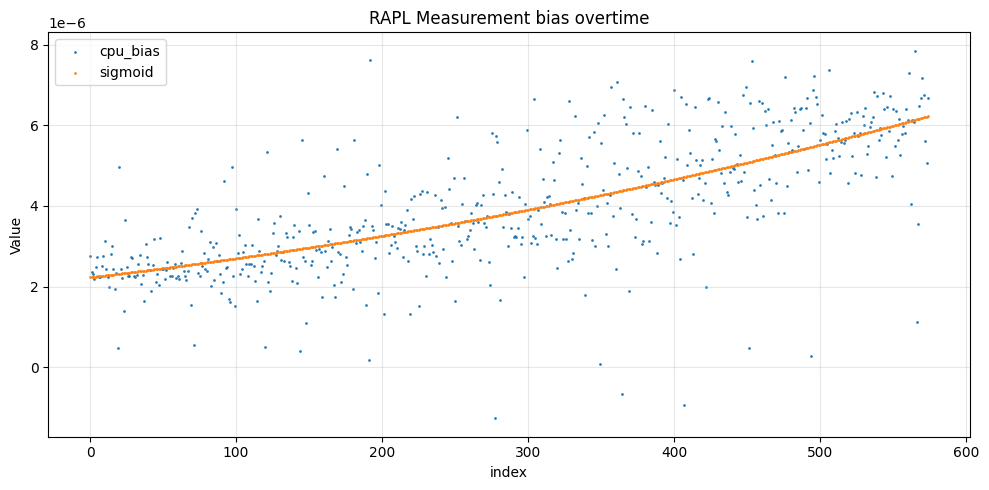

In [89]:
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

def fit_sigmoid(x, y):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    def sigmoid(x, L, k, x0):
        return L / (1 + np.exp(-k * (x - x0)))

    L0 = float(np.nanmax(y))
    k0 = 1.0 / (np.nanstd(x) + 1e-9)
    x00 = float(np.nanmedian(x))

    popt, _ = curve_fit(sigmoid, x, y, p0=[L0, k0, x00], maxfev=20000)

    y_pred = sigmoid(x, *popt)

    rss = np.sum((y - y_pred)**2)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)

    n = len(y)
    k = len(popt)
    aic = 2*k + n * np.log(rss / n)

    return {
        "params": popt,
        "y_pred": y_pred,
        "r2": r2,
        "rss": rss,
        "mse": mse,
        "rmse": rmse,
        "aic": aic
    }

result_sigmoid = fit_sigmoid(trapezoid_result_stacked_increase["index"], trapezoid_result_stacked_increase["cpu_bias"])
print(result_sigmoid)
print(trapezoid_result_stacked_increase["index"].shape)
print(trapezoid_result_stacked_increase["cpu_bias"].shape)
trapezoid_result_stacked_increase["sigmoid"] = result_sigmoid["y_pred"]
plot_columns_scatter(trapezoid_result_stacked_increase, columns=["cpu_bias", "sigmoid"] , x_col="index", markersize=1, title="RAPL Measurement bias overtime")



Conclusion is that this demonstrate no significant sigmoidal relationship, 
It is instead quantifiable by quadratic or cubic relationships. Possibly Sine relationship. 

In [ ]:
import matplotlib.pyplot as plt

def autopct_conditional(pct, threshold=5):
    return f"{pct:.1f}%" if pct >= threshold else ""

def plot_pie_from_tuples(data, filename=None, dpi=300):
    """
    Plot a pie chart given a list of (name, color, value) tuples.

    Parameters
    ----------
    data : list of tuples
        Each tuple must be (label:str, color:str, value:float).
    filename : str or None
        If given, saves to file (pdf, png, svg depending on extension).
    dpi : int
        DPI only used for raster formats. Ignored for vector formats.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """

    labels  = [t[0] for t in data]
    colors  = [t[1] for t in data]
    values  = [t[2] for t in data]

    fig, ax = plt.subplots(figsize=(4,4))
    ax.pie(
        values,
        #labels=labels,
        colors=colors,
        autopct=lambda pct: autopct_conditional(pct, threshold=1),
        startangle=90,
        pctdistance=1.2,
    )
    ax.axis('equal')  # keep circular

    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=dpi)

    return fig, ax

In [ ]:
import matplotlib.pyplot as plt

def autopct_conditional(pct, threshold=5):
    return f"{pct:.1f}%" if pct >= threshold else ""

def plot_pie_from_tuples(data, filename=None, dpi=300):
    """
    Plot a pie chart given a list of (name, color, value) tuples.

    Parameters
    ----------
    data : list of tuples
        Each tuple must be (label:str, color:str, value:float).
    filename : str or None
        If given, saves to file (pdf, png, svg depending on extension).
    dpi : int
        DPI only used for raster formats. Ignored for vector formats.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """

    labels  = [t[0] for t in data]
    colors  = [t[1] for t in data]
    values  = [t[2] for t in data]

    fig, ax = plt.subplots(figsize=(4,4))
    ax.pie(
        values,
        #labels=labels,
        colors=colors,
        autopct=lambda pct: autopct_conditional(pct, threshold=1),
        startangle=90,
        pctdistance=1.2,
    )
    ax.axis('equal')  # keep circular

    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=dpi)

    return fig, ax

In [16]:
#duration 
def observation_duration(df: pd.DataFrame, time_col: str = "timestamp") -> str:
    """
    Compute total duration (start → end) from a timestamp column in nanoseconds.
    Returns formatted string 'Hh Mm Ss'.
    """
    start_ns = df[time_col].iloc[0]
    end_ns = df[time_col].iloc[-1]
    delta_ns = end_ns - start_ns

    total_seconds = delta_ns / 1e9
    hours = int(total_seconds // 3600)
    minutes = int((total_seconds % 3600) // 60)
    seconds = total_seconds % 60

    return f"{hours}h {minutes}m {seconds:.3f}s"
print(observation_duration(rapl_teensy_merged))
print((24*60+60) / 27)

0h 20m 46.607s
55.55555555555556


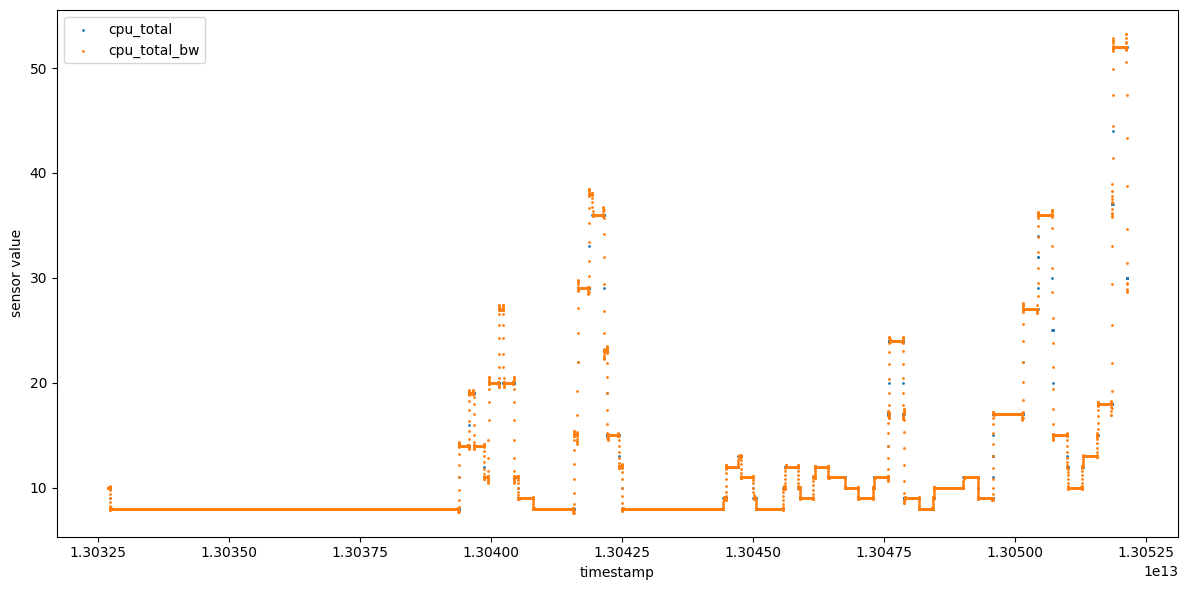

In [95]:
temp_df = rapl_teensy_running_average.iloc[2000:20000]#.iloc[::1]
cols=["cpu_total","cpu_total_bw"]
#cols=["cpu_total"]

plt.figure(figsize=(12,6))

for col in cols:
    plt.scatter(temp_df['timestamp'], temp_df[col], label=col, s=1)

plt.xlabel("timestamp")
plt.ylabel("sensor value")
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
print(rapl_teensy_merged['timestamp'].diff().head(5))

0          NaN
1    1010362.0
2    1005250.0
3     998234.0
4     999057.0
Name: timestamp, dtype: float64


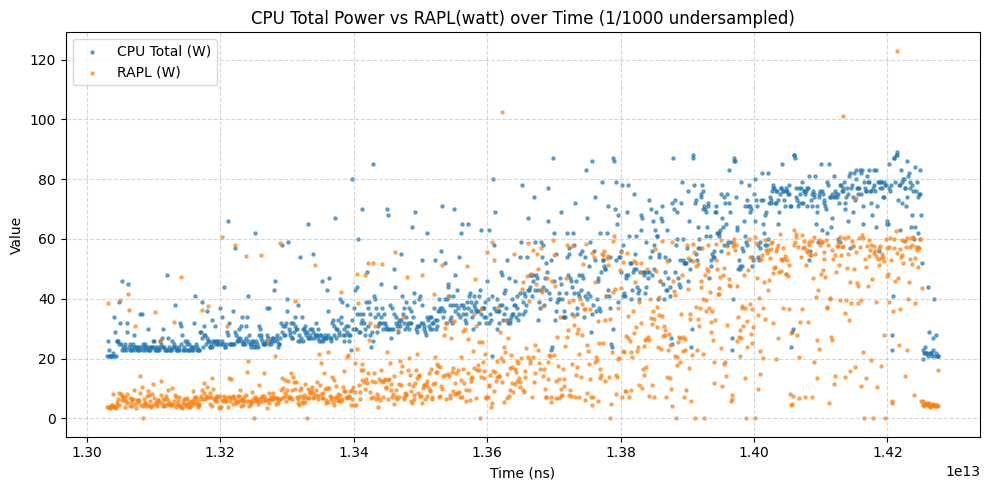

In [127]:
plot_cpu_vs_energy(rapl_teensy_merged, cpu_col = "abs_total")

This data is rather noisy. The microservice benchmarks are more dynamic than SPEC. 

In [125]:
idx = (rapl_teensy_merged["timestamp_1"] - 1.04e13).abs().idxmin()
print(idx/1499999)
print(150*idx/1499999)

0.0
0.0


In [128]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

def cliffs_delta(x, y):
    """
    Compute Cliff's Delta effect size between two independent samples.
    δ ∈ [-1, 1]; magnitude interpreted as:
      |δ| < 0.147 → negligible
      |δ| < 0.33  → small
      |δ| < 0.474 → medium
      |δ| ≥ 0.474 → large
    """
    nx, ny = len(x), len(y)
    # count all pairwise comparisons
    gt = np.sum(x[:, None] > y)
    lt = np.sum(x[:, None] < y)
    delta = (gt - lt) / (nx * ny)
    return delta


def compare_column_means_nonparametric(df, time_col="timestamp_1",
                                       start1=6.52e13, start2=6.56e13, window=500,
                                       cols_range=range(ord('A'), ord('Z')+1)):
    """
    Compare A_2–Z_2 columns between two time windows using non-parametric tests.
    Reports direction, significance (Mann–Whitney U), and effect size (Cliff's Delta).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing timestamp and sensor columns.
    time_col : str
        Timestamp column (nanoseconds).
    start1, start2 : float
        Center timestamps for the two regions.
    window : int
        Number of samples before and after each timestamp to include.
    cols_range : iterable
        Character range to define A–Z columns.

    Returns
    -------
    pd.DataFrame
        Per-column statistics: mean_before, mean_after, delta_mean,
        U_stat, p_value, direction, cliffs_delta, and effect_magnitude.
    """

    # Build expected column names: A_2, B_2, ..., Z_2
    cols = [f"{chr(c)}_2" for c in cols_range if f"{chr(c)}_2" in df.columns]

    # Find closest indices to given timestamps
    idx1 = (df[time_col] - start1).abs().idxmin()
    idx2 = (df[time_col] - start2).abs().idxmin()

    # Define window slices
    slice1 = df.iloc[max(0, idx1 - window): idx1 + window]
    slice2 = df.iloc[max(0, idx2 - window): idx2 + window]

    results = []

    for col in cols:
        x1 = slice1[col].dropna().to_numpy()
        x2 = slice2[col].dropna().to_numpy()

        if len(x1) < 10 or len(x2) < 10:
            continue  # skip if too few points

        # Non-parametric Mann–Whitney U test
        U, p = mannwhitneyu(x1, x2, alternative="two-sided")

        mean1, mean2 = x1.mean(), x2.mean()
        delta_mean = mean2 - mean1
        direction = "increase" if delta_mean > 0 else "decrease"

        # Cliff's Delta effect size
        delta = cliffs_delta(x1, x2)
        magnitude = (
            "negligible" if abs(delta) < 0.147 else
            "small" if abs(delta) < 0.33 else
            "medium" if abs(delta) < 0.474 else
            "large"
        )

        results.append({
            "column": col,
            "mean_before": mean1,
            "mean_after": mean2,
            "delta_mean": delta_mean,
            "abs_delta": abs(delta_mean),
            "U_stat": U,
            "p_value": p,
            "direction": direction,
            "cliffs_delta": delta,
            "effect_magnitude": magnitude
        })

    result_df = pd.DataFrame(results).sort_values(["p_value", "abs_delta"])

    print("Top statistically significant changes:")
    print(result_df.head(5))
    return result_df

print(compare_column_means_nonparametric(rapl_teensy_merged))

Top statistically significant changes:
  column  mean_before  mean_after  delta_mean  abs_delta    U_stat  p_value  \
0    A_2          1.0         1.0         0.0        0.0  125500.5      1.0   
1    B_2          0.0         0.0         0.0        0.0  125500.5      1.0   
2    C_2          0.0         0.0         0.0        0.0  125500.5      1.0   
3    D_2          0.0         0.0         0.0        0.0  125500.5      1.0   
4    H_2          0.0         0.0         0.0        0.0  125500.5      1.0   

  direction  cliffs_delta effect_magnitude  
0  decrease           0.0       negligible  
1  decrease           0.0       negligible  
2  decrease           0.0       negligible  
3  decrease           0.0       negligible  
4  decrease           0.0       negligible  
   column  mean_before  mean_after  delta_mean  abs_delta    U_stat  p_value  \
0     A_2     1.000000    1.000000         0.0        0.0  125500.5      1.0   
1     B_2     0.000000    0.000000         0.0        0.

In [145]:
import pandas as pd
import re

def rename_single_letter_cols(df: pd.DataFrame, suffix: str = "_2") -> pd.DataFrame:
    """
    Rename all single-letter column names (case-insensitive) by appending a suffix.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    suffix : str, optional
        String to append to single-letter columns (default '_2').

    Returns
    -------
    pd.DataFrame
        New DataFrame with renamed columns.
    """
    rename_map = {
        col: f"{col}{suffix}" for col in df.columns
        if re.fullmatch(r"[A-Za-z]", str(col))
    }
    return df.rename(columns=rename_map)

Top statistically significant changes:
  column  mean_before  mean_after  delta_mean  abs_delta    U_stat  p_value  \
0    A_2     1.354901    1.354901         0.0        0.0  500000.0      1.0   
1    B_2     0.080071    0.080071         0.0        0.0  500000.0      1.0   
2    C_2     1.107114    1.107114         0.0        0.0  500000.0      1.0   
3    D_2     0.205898    0.205898         0.0        0.0  500000.0      1.0   
4    H_2     0.011439    0.011439         0.0        0.0  500000.0      1.0   

  direction  cliffs_delta effect_magnitude  
0  decrease           0.0       negligible  
1  decrease           0.0       negligible  
2  decrease           0.0       negligible  
3  decrease           0.0       negligible  
4  decrease           0.0       negligible  
   column  mean_before  mean_after  delta_mean  abs_delta    U_stat  p_value  \
0     A_2     1.354901    1.354901         0.0        0.0  500000.0      1.0   
1     B_2     0.080071    0.080071         0.0        0.

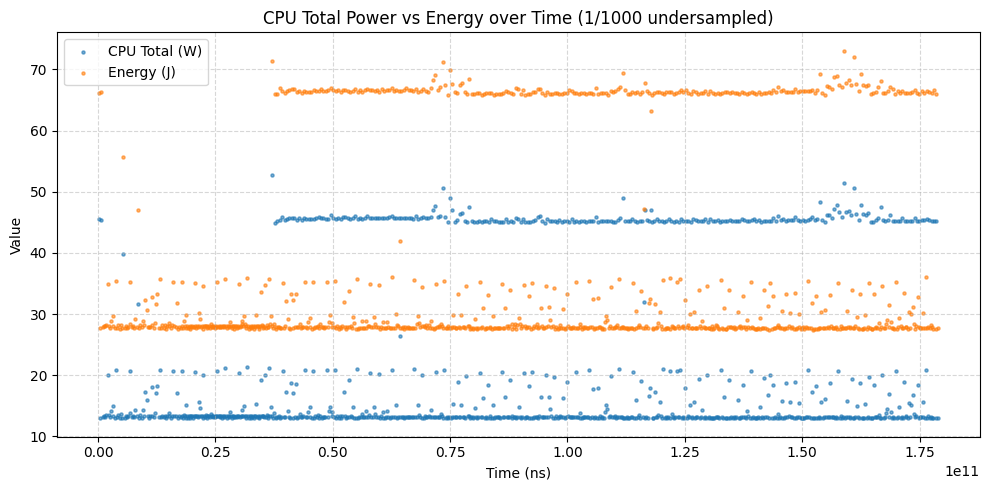

In [152]:
df_onlyTeensy = rename_single_letter_cols(df)
df_onlyTeensy["timestamp_1"] = df_onlyTeensy["timestamp"] 
print(compare_column_means_nonparametric(df_onlyTeensy))
df_onlyTeensy["cpu_total"] = (rapl_teensy_merged["Y_2"].astype("float32") + rapl_teensy_merged["Z_2"].astype("float32")).astype("float32")
df_onlyTeensy["abs_total"] = (rapl_teensy_merged["A_2"]+rapl_teensy_merged["B_2"]+rapl_teensy_merged["C_2"]+rapl_teensy_merged["D_2"]+rapl_teensy_merged["H_2"]+rapl_teensy_merged["I_2"]+rapl_teensy_merged["J_2"]+rapl_teensy_merged["K_2"]+rapl_teensy_merged["Y_2"]+rapl_teensy_merged["Z_2"]+rapl_teensy_merged["O_2"]+rapl_teensy_merged["P_2"]+rapl_teensy_merged["Q_2"]+rapl_teensy_merged["R_2"]+rapl_teensy_merged["U_2"]+rapl_teensy_merged["V_2"])

plot_cpu_vs_energy(df_onlyTeensy, time_col="timestamp", cpu_col="cpu_total", energy_col="abs_total", sample_factor=1000)


here we identify P, Q, R, A and C as the main contributor to this increase. 

We identified using time stamps that the benchmark that cause this to occur is 549.fotonik3d_r refrate base

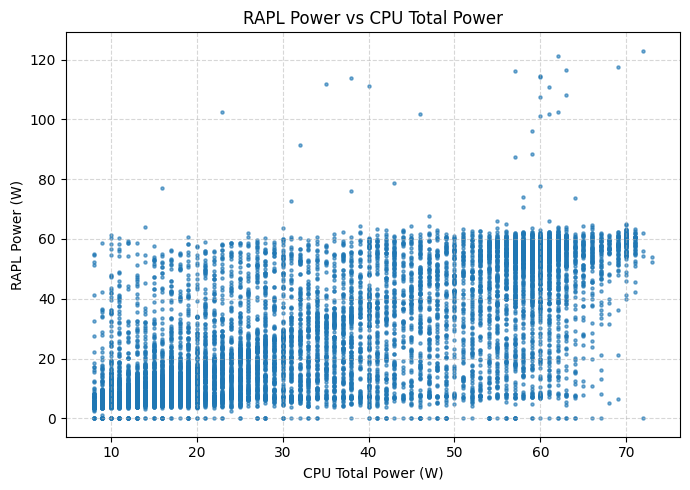

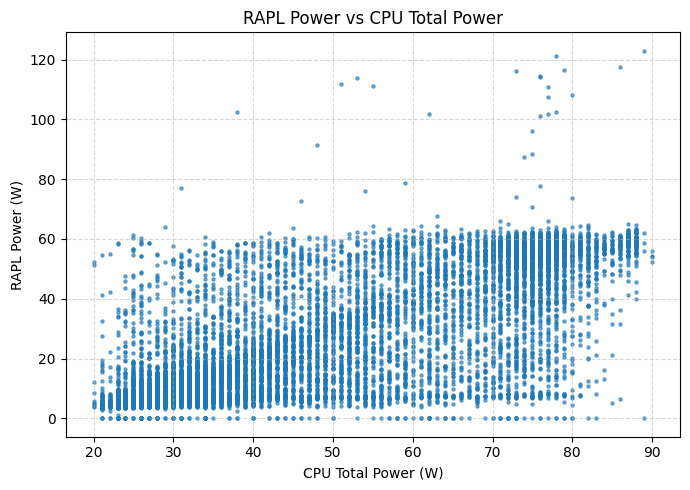

In [94]:
import matplotlib.pyplot as plt

def plot_cpu_vs_rapl(df, cpu_col="cpu_total", rapl_col="power"):
    """
    Scatter plot of RAPL energy vs CPU total power.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing cpu_total and energy columns.
    cpu_col : str, default 'cpu_total'
        Column name for CPU total (x-axis).
    rapl_col : str, default 'energy'
        Column name for RAPL energy (y-axis).
    """
    df = df.iloc[::100, :]
    plt.figure(figsize=(7, 5))
    plt.scatter(df[cpu_col], df[rapl_col], s=5, alpha=0.6, color="tab:blue")

    plt.xlabel("CPU Total Power (W)")
    plt.ylabel("RAPL Power (W)")
    plt.title("RAPL Power vs CPU Total Power")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
plot_cpu_vs_rapl(rapl_teensy_merged)
plot_cpu_vs_rapl(rapl_teensy_merged,cpu_col="abs_total")

In [95]:
print(rapl_teensy_merged.columns)

Index(['timestamp', 'energy_pkg', 'energy_dram', 'energy_psys', 'energy',
       'power', 'dram_rapl', 'timestamp_1', 'timestamp_2', 'A_2', 'B_2', 'C_2',
       'D_2', 'H_2', 'I_2', 'J_2', 'K_2', 'Y_2', 'Z_2', 'O_2', 'P_2', 'Q_2',
       'R_2', 'U_2', 'V_2', 'timestamp_2_2', 'timestamp_diff', 'cpu_total',
       'abs_total'],
      dtype='object')


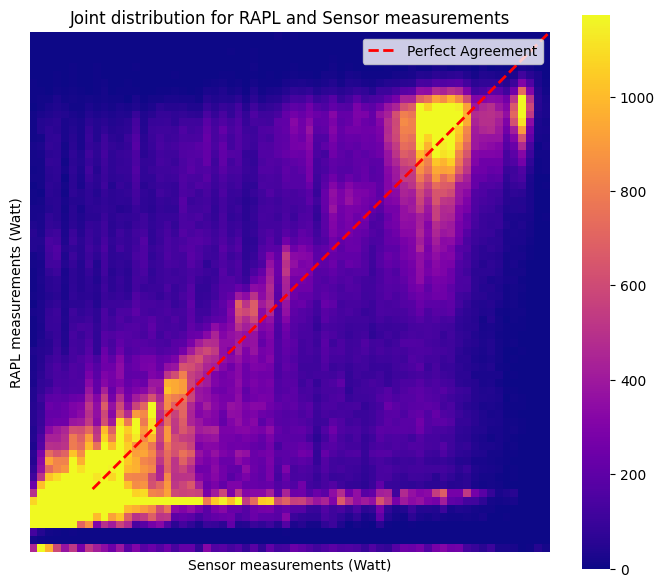

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def heatmap_2d_correlation(df, col_x, col_y, bins=80, cmap="plasma"):
    """
    Create a 2D heatmap (binned density) between two numeric columns.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame
    col_x : str
        First column name
    col_y : str
        Second column name
    bins : int
        Number of bins along both axes (default 80)
    cmap : str
        Heatmap color scheme
        
    Returns
    -------
    None
    """

    # Drop NaN
    data = df[[col_x, col_y]].dropna()

    x = data[col_x].astype(np.float32).to_numpy()
    y = data[col_y].astype(np.float32).to_numpy()

    # 2D histogram
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)

    #ceiling
    ceiling = np.percentile(heatmap, 97)   # keep bottom % dynamic
    heatmap_clipped = np.clip(heatmap, 0, ceiling)

    # Log scale (add epsilon to prevent log(0))
    heatmap_log = np.log1p(heatmap)

    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    xmin, xmax = xedges[0], xedges[-1]
    ymin, ymax = yedges[0], yedges[-1]
    low  = max(xmin, ymin)
    high = min(xmax, ymax)
    

    # Plot
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        heatmap_clipped.T,
        cmap=cmap,
        cbar=True,
        xticklabels=False,
        yticklabels=False,
        square=True
    )
    plt.gca().invert_yaxis()
    plt.xlabel("Sensor measurements (Watt)")
    plt.ylabel("RAPL measurements (Watt)")
    plt.title(f"Joint distribution for RAPL and Sensor measurements")
    plt.tight_layout()
    plt.plot([low, high], [low, high],
            '--', color='red', linewidth=2,
            label='Perfect Agreement')
    plt.legend(loc='upper right')
    plt.show()

temp_df_heatmap = pd.DataFrame()
temp_df_heatmap = rapl_teensy_merged[rapl_teensy_merged["power"] <= 70]
heatmap_2d_correlation(temp_df_heatmap, "cpu_total", "power", bins=66)

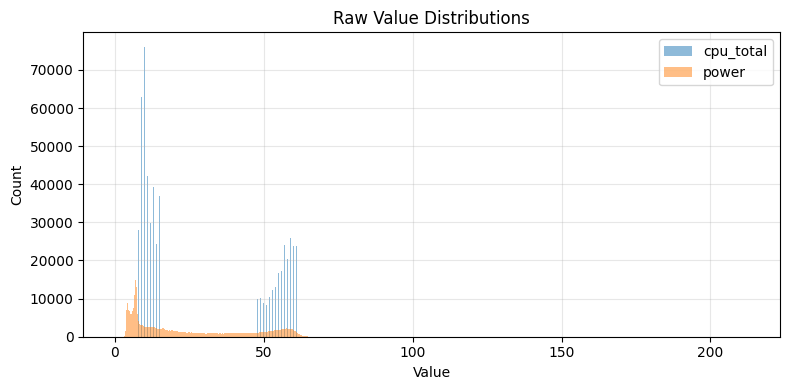

((array([0, 0, 0, ..., 0, 0, 0]),
  array([0.00000000e+00, 1.00000001e-01, 2.00000003e-01, ...,
         2.12500003e+02, 2.12600003e+02, 2.12700003e+02])),
 (array([14757,     0,     0, ...,     0,     0,     1]),
  array([0.00000000e+00, 1.00000001e-01, 2.00000003e-01, ...,
         2.12500003e+02, 2.12600003e+02, 2.12700003e+02])))

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def show_raw_distributions(
        df: pd.DataFrame,
        col1: str,
        col2: str,
        step_size: float,
        overlay=True
    ):
    """
    Show the distribution of raw observations between two numeric columns
    using user-defined bin step size.

    Parameters
    ----------
    df : pd.DataFrame
        Source data
    col1 : str
        First column name
    col2 : str
        Second column name
    step_size : float
        Histogram bin width
    overlay : bool
        If True → overlay histograms; otherwise → side-by-side subplots

    Returns
    -------
    (counts1, bins), (counts2, bins)
    """

    # Extract values
    vals1 = df[col1].dropna()
    vals2 = df[col2].dropna()

    # Determine global bin range
    minv = min(vals1.min(), vals2.min())
    maxv = max(vals1.max(), vals2.max())

    bins = np.arange(minv, maxv + step_size, step_size)

    counts1, edges1 = np.histogram(vals1, bins=bins)
    counts2, edges2 = np.histogram(vals2, bins=bins)

    # Plot
    if overlay:
        plt.figure(figsize=(8,4))
        plt.hist(vals1, bins=bins, alpha=0.5, label=col1)
        plt.hist(vals2, bins=bins, alpha=0.5, label=col2)
        plt.xlabel("Value")
        plt.ylabel("Count")
        plt.title("Raw Value Distributions")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        fig, axs = plt.subplots(1, 2, figsize=(10,4), sharey=True)
        axs[0].hist(vals1, bins=bins)
        axs[0].set_title(col1)
        axs[1].hist(vals2, bins=bins)
        axs[1].set_title(col2)
        for ax in axs:
            ax.set_xlabel("Value")
            ax.set_ylabel("Count")
            ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return (counts1, edges1), (counts2, edges2)

show_raw_distributions(rapl_teensy_merged, col1="cpu_total", col2="power", step_size=0.1)

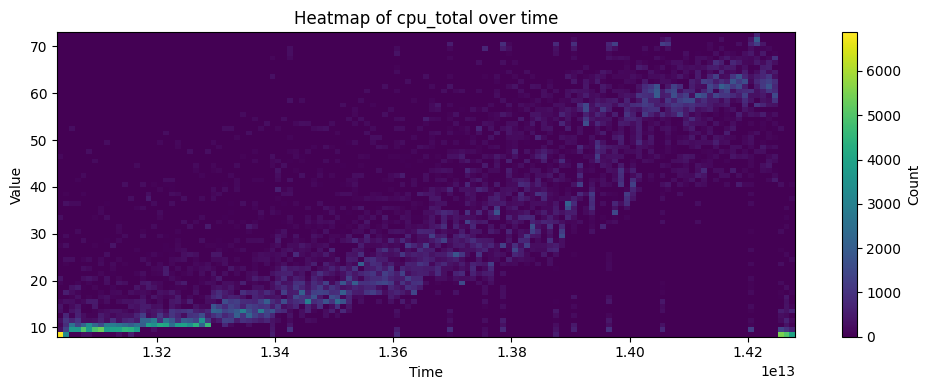

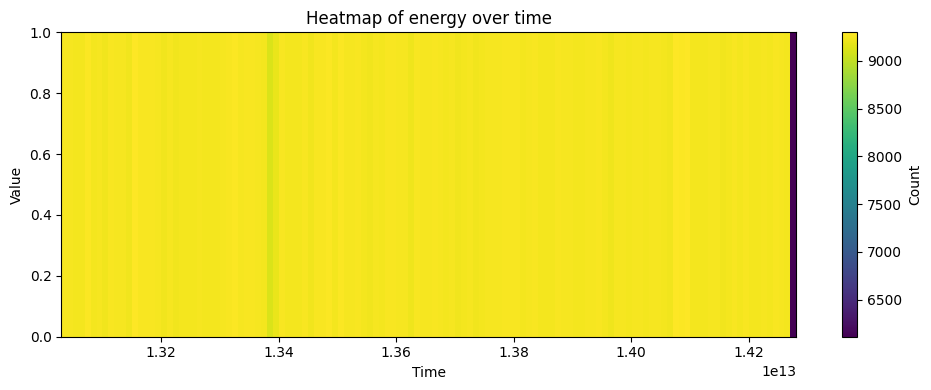

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_time_value_heatmap(
        df: pd.DataFrame,
        time_col: str,
        value_col: str,
        time_step: float,
        value_step: float,
        cmap="viridis"
    ):
    """
    Plots a 2D heatmap of (time vs value) binned by given step sizes.

    Parameters
    ----------
    df : pd.DataFrame
        Source data
    time_col : str
        Timestamp column
    value_col : str
        Value column
    time_step : float
        Bin width along time axis
    value_step : float
        Bin width along value axis
    cmap : str
        Matplotlib colormap

    Returns
    -------
    H, xedges, yedges
        2D histogram counts and edges
    """

    t = df[time_col].values
    v = df[value_col].values

    # Compute bins
    t_min, t_max = t.min(), t.max()
    v_min, v_max = v.min(), v.max()

    t_bins = np.arange(t_min, t_max + time_step, time_step)
    v_bins = np.arange(v_min, v_max + value_step, value_step)

    # 2D histogram
    H, xedges, yedges = np.histogram2d(t, v, bins=[t_bins, v_bins])

    plt.figure(figsize=(10,4))
    plt.pcolormesh(xedges, yedges, H.T, cmap=cmap, shading='auto')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title(f"Heatmap of {value_col} over time")
    plt.colorbar(label="Count")
    plt.tight_layout()
    plt.show()

    return H, xedges, yedges

H, xedges, yedges = plot_time_value_heatmap(
    rapl_teensy_merged,
    time_col="timestamp",
    value_col="cpu_total",
    time_step=10_000_000_000,
    value_step=1
)

H, xedges, yedges = plot_time_value_heatmap(
    rapl_teensy_merged,
    time_col="timestamp",
    value_col="energy",
    time_step=10_000_000_000,
    value_step=1
)

In [45]:
import scipy.stats as stats
import numpy as np

def nonparametric_correlation(df, col_x="cpu_total", col_y="power"):
    """
    Compute non-parametric correlation between two columns (Spearman and Kendall).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing both columns.
    col_x : str
        First variable (e.g. CPU total power).
    col_y : str
        Second variable (e.g. RAPL or measured power).

    Returns
    -------
    dict
        Spearman and Kendall correlation results.
    """
    # Drop missing values
    data = df[[col_x, col_y]].dropna()

    x = data[col_x].to_numpy()
    y = data[col_y].to_numpy()

    # Spearman rank correlation (monotonic relationship)
    spearman_rho, spearman_p = stats.spearmanr(x, y)

    # Kendall Tau correlation (ordinal consistency)
    kendall_tau, kendall_p = stats.kendalltau(x, y)

    results = {
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
        "kendall_tau": kendall_tau,
        "kendall_p": kendall_p,
        "n": len(data)
    }

    print(f"Spearman ρ = {spearman_rho:.4f} (p = {spearman_p:.3e})")
    print(f"Kendall τ = {kendall_tau:.4f} (p = {kendall_p:.3e})")
    print(f"Samples used: {len(data)}")

    return results

print(nonparametric_correlation(rapl_teensy_merged))


Spearman ρ = 0.4383 (p = 0.000e+00)
Kendall τ = 0.3016 (p = 0.000e+00)
Samples used: 359999
{'spearman_rho': np.float64(0.43828121694263084), 'spearman_p': np.float64(0.0), 'kendall_tau': np.float64(0.3015754831530665), 'kendall_p': np.float64(0.0), 'n': 359999}


In [137]:
print(nonparametric_correlation(rapl_teensy_merged, col_x="A_2", col_y="C_2"))
print(nonparametric_correlation(rapl_teensy_merged, col_x="Y_2", col_y="Z_2")) #sanity test here, Y and Z is both CPU 
print(nonparametric_correlation(rapl_teensy_merged, col_x="R_2", col_y="P_2"))
print(nonparametric_correlation(rapl_teensy_merged, col_x="Q_2", col_y="P_2"))




Spearman ρ = 0.8813 (p = 0.000e+00)
Kendall τ = 0.8177 (p = 0.000e+00)
Samples used: 999999
{'spearman_rho': np.float64(0.8812594980327332), 'spearman_p': np.float64(0.0), 'kendall_tau': np.float64(0.8176720059893758), 'kendall_p': np.float64(0.0), 'n': 999999}
Spearman ρ = 0.8900 (p = 0.000e+00)
Kendall τ = 0.7589 (p = 0.000e+00)
Samples used: 999999
{'spearman_rho': np.float64(0.8899831442419877), 'spearman_p': np.float64(0.0), 'kendall_tau': np.float64(0.7588944803942239), 'kendall_p': np.float64(0.0), 'n': 999999}
Spearman ρ = 0.8817 (p = 0.000e+00)
Kendall τ = 0.8133 (p = 0.000e+00)
Samples used: 999999
{'spearman_rho': np.float64(0.8816721527113947), 'spearman_p': np.float64(0.0), 'kendall_tau': np.float64(0.8133338836992846), 'kendall_p': np.float64(0.0), 'n': 999999}
Spearman ρ = 0.8694 (p = 0.000e+00)
Kendall τ = 0.7979 (p = 0.000e+00)
Samples used: 999999
{'spearman_rho': np.float64(0.8693805206856898), 'spearman_p': np.float64(0.0), 'kendall_tau': np.float64(0.79793788543223

In [22]:
# CHOICE 1
def sum_y_z_with_timestamp(df: pd.DataFrame, col_y: str = "Y", col_z: str = "Z") -> pd.DataFrame:
    """
    Return a new DataFrame with timestamp and the sum of col_y and col_z.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with timestamp and sensor columns.
        col_y (str): Name of first column to sum (default: "Y")
        col_z (str): Name of second column to sum (default: "Z")
    
    Returns:
        pd.DataFrame: DataFrame with 'timestamp' and a new column 'Y_plus_Z'
    """
    return pd.DataFrame({
        "timestamp": df["timestamp"],
        f"{col_y}_plus_{col_z}": df[col_y] + df[col_z]
    })

result = sum_y_z_with_timestamp(corrected_df)
print(result)

      timestamp   Y_plus_Z
0     544634818  12.189750
1     568634831  11.747319
2     592634837  19.543268
3     616634842  14.813827
4     640634848  11.732063
..          ...        ...
285  7366972305  69.110851
286  7390972347  68.103939
287  7414972360  71.017883
288  7438972384  44.761864
289  7462972403  18.109179

[290 rows x 2 columns]


In [109]:
import pandas as pd
import numpy as np

def analyze_variance(df, col):
    """
    Compute descriptive variance statistics for a numeric column.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    col : str
        Name of the numeric column to analyze.

    Returns
    -------
    dict
        Dictionary containing mean, variance, std, coefficient of variation, and IQR.
    """
    x = df[col].dropna()

    stats = {
        "count": len(x),
        "mean": float(np.mean(x)),
        "variance": float(np.var(x, ddof=1)),  # sample variance
        "std_dev": float(np.std(x, ddof=1)),
        "coefficient_of_variation": float(np.std(x, ddof=1) / np.mean(x)) if np.mean(x) != 0 else np.nan,
        "min": float(np.min(x)),
        "max": float(np.max(x)),
        "iqr": float(np.percentile(x, 75) - np.percentile(x, 25))
    }

    print(f"--- Variance Analysis for '{col}' ---")
    for k, v in stats.items():
        print(f"{k:>25}: {v}")
    return stats
print(analyze_variance(rapl_teensy_merged, "power"))
print(analyze_variance(rapl_teensy_merged, "cpu_total"))


--- Variance Analysis for 'power' ---
                    count: 359999
                     mean: 40.06246566772461
                 variance: 446.1170654296875
                  std_dev: 21.121482849121094
 coefficient_of_variation: 0.5272137522697449
                      min: 0.0
                      max: 172.4046173095703
                      iqr: 35.36875534057617
{'count': 359999, 'mean': 40.06246566772461, 'variance': 446.1170654296875, 'std_dev': 21.121482849121094, 'coefficient_of_variation': 0.5272137522697449, 'min': 0.0, 'max': 172.4046173095703, 'iqr': 35.36875534057617}
--- Variance Analysis for 'cpu_total' ---
                    count: 359999
                     mean: 50.42235565185547
                 variance: 325.2079772949219
                  std_dev: 18.033523559570312
 coefficient_of_variation: 0.3576493561267853
                      min: 8.238380432128906
                      max: 73.41311645507812
                      iqr: 16.080093383789062
{'count': 35

In [133]:
#check normality at points
import numpy as np
import pandas as pd
from scipy.stats import shapiro, normaltest, anderson

def test_local_normality_at_points(
    df: pd.DataFrame,
    timestamp_col: str,
    value_col: str,
    points: list,
    N: int = 20,
    alpha: float = 0.05,
    method: str = "shapiro"
):
    """
    For each timestamp in `points`, find the nearest timestamp in the DataFrame,
    extract a window of N samples centered on it, and test if that segment is normally distributed.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with timestamp and value columns.
    timestamp_col : str
        Name of the timestamp column (must be integer-like, sorted ascending).
    value_col : str
        Name of the value column to test.
    points : list[float or int]
        List of timestamps (e.g., 1.03e13) where normality should be checked.
    N : int, optional
        Number of samples in the local window (default 20).
    alpha : float, optional
        Significance level for normality tests (default 0.05).
    method : {'shapiro', 'dagostino', 'anderson'}
        Statistical test to use for normality.

    Returns
    -------
    pd.DataFrame
        Columns: ['target_timestamp', 'nearest_timestamp', 'index', 'p_value', 'is_normal']
    """
    timestamps = df[timestamp_col].to_numpy(dtype=np.uint64)
    values = df[value_col].to_numpy(dtype=float)
    half = N // 2

    results = []
    for p in points:
        # Convert to uint64-compatible int
        p_int = np.uint64(round(p))
        # Find nearest index
        idx = np.abs(timestamps - p_int).argmin()
        start = max(0, idx - half)
        end = min(len(df), idx + half + 1)
        window = values[start:end]

        if len(window) < 3:
            results.append((p, timestamps[idx], idx, np.nan, np.nan))
            continue

        if method == "shapiro":
            stat, pval = shapiro(window)
            is_norm = pval > alpha
        elif method == "dagostino":
            stat, pval = normaltest(window)
            is_norm = pval > alpha
        elif method == "anderson":
            res = anderson(window)
            idx_crit = np.searchsorted(res.significance_level, alpha * 100, side="right") - 1
            idx_crit = np.clip(idx_crit, 0, len(res.critical_values) - 1)
            is_norm = res.statistic < res.critical_values[idx_crit]
            pval = np.nan
        else:
            raise ValueError(f"Unknown method: {method}")

        results.append((p, timestamps[idx], idx, pval, is_norm))

    return pd.DataFrame(results, columns=[
        "target_timestamp", "nearest_timestamp", "index", "p_value", "is_normal"
    ])

points = [6.52e13, 6.58e13]

res = test_local_normality_at_points(rapl_teensy_merged, "timestamp", "power", points, N=2000, method="shapiro")
print(res)

res = test_local_normality_at_points(rapl_teensy_merged, "timestamp", "cpu_total", points, N=2000, method="shapiro")
print(res)


   target_timestamp  nearest_timestamp   index       p_value  is_normal
0      6.520000e+13     65200000193882  196289  7.952912e-45      False
1      6.580000e+13     65800000984742  796290  1.636132e-46      False
   target_timestamp  nearest_timestamp   index       p_value  is_normal
0      6.520000e+13     65200000193882  196289  1.477097e-47      False
1      6.580000e+13     65800000984742  796290  3.792492e-62      False
